<center>
<strong>Appendix</strong>
</center>

In [1]:
import pandas as pd
import glob

# Load all CSV files from 'logs' directory
log_files = glob.glob('benchmark/logs/*.csv')
dfs = []
for file in log_files:
    df = pd.read_csv(file)
    df['sourcefile'] = file  # Optionally keep source info
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(df)} rows from {len(log_files)} log files.")
display(df.head())

Loaded 3400 rows from 86 log files.


,func,algo,dim,seed,best,evals,seconds,restarts,evals_to_target,success,params,sourcefile
0,ackley,bipop_sep,100,0,6.363354e-12,114178,24.034695,6,38226.0,1,"{""seed"": 0, ""budget"": 500000, ""bounds"": ""[-5,5...",benchmark/logs\ackley_d100_bipop_sep.csv
1,ackley,bipop_sep,100,1,7.749357e-13,55509,18.911156,6,21139.0,1,"{""seed"": 1, ""budget"": 500000, ""bounds"": ""[-5,5...",benchmark/logs\ackley_d100_bipop_sep.csv
2,ackley,bipop_sep,100,2,9.454659e-13,95789,33.080826,7,21847.0,1,"{""seed"": 2, ""budget"": 500000, ""bounds"": ""[-5,5...",benchmark/logs\ackley_d100_bipop_sep.csv
3,ackley,bipop_sep,100,3,7.940759e-12,112996,22.836953,6,38575.0,1,"{""seed"": 3, ""budget"": 500000, ""bounds"": ""[-5,5...",benchmark/logs\ackley_d100_bipop_sep.csv
4,ackley,bipop_sep,100,4,7.766676e-12,113136,27.618870,6,41864.0,1,"{""seed"": 4, ""budget"": 500000, ""bounds"": ""[-5,5...",benchmark/logs\ackley_d100_bipop_sep.csv


In [2]:
targets = {
    'sphere':      {10: 1e-10, 20: 1e-10, 50: 1e-10, 100: 1e-10, 150: 1e-10, 200: 1e-10},
    'ellipsoid':   {10: 1e-8, 20: 1e-8, 50: 1e-8,  100: 1e-8, 150: 1e-8, 200: 1e-8},
    'rastrigin':   {10: 200,     20: 200,     50: 200,     100: 200,   150: 200, 200: 200},
    'ackley':      {10: 1e-8, 20: 1e-8, 50: 1e-8,  100: 1e-8, 150: 1e-8, 200: 1e-8},
    'rosenbrock':  {10: 200,     20: 200,    50: 200,     100: 200, 150: 200, 200: 200},
}

def get_target(row):
    return targets[row['func']][row['dim']]

df['target'] = df.apply(get_target, axis=1)
df['success'] = (df['best'] <= df['target']).astype(int)


In [3]:
import numpy as np

PLANNED_RUNS = 20  # how many runs you intended per (func, dim, algo)

per_run = (
    df.groupby(['func', 'dim', 'algo', 'seed'], as_index=False)
      .agg(
          # 1 if this run ever hit target
          run_success=('success', 'max'),

          # best fitness over the run
          best_fitness=('best', 'min'),

          # final evals / time / restarts
          evals_final=('evals', 'max'),
          seconds_final=('seconds', 'max'),
          restarts_final=('restarts', 'max'),

          # earliest evals_to_target if available, else NaN
          evals_to_target=('evals_to_target',
                           lambda s: s[s.notna()].min() if s.notna().any() else np.nan),
      )
)

print("per_run shape:", per_run.shape)
display(per_run.head())


per_run shape: (1700, 10)


,func,dim,algo,seed,run_success,best_fitness,evals_final,seconds_final,restarts_final,evals_to_target
0,ackley,20,bipop_full,0,1,7.969181e-12,500000,77.573509,9,10644.0
1,ackley,20,bipop_full,1,1,1.258105e-12,500000,73.615945,9,5641.0
2,ackley,20,bipop_full,2,1,1.265210e-12,500000,71.673165,9,5547.0
3,ackley,20,bipop_full,3,1,5.741629e-12,500000,72.164766,9,9857.0
4,ackley,20,bipop_full,4,1,8.203660e-12,500000,73.797337,9,11331.0


In [4]:
# Aggregate over runs that actually ran
agg_raw = (
    per_run.groupby(['func', 'dim', 'algo'], as_index=False)
      .agg(
          n_runs=('seed', 'size'),                 # how many runs actually ran
          n_success=('run_success', 'sum'),        # how many of those succeeded
          success_rate_actual=('run_success', 'mean'),

          mean_best=('best_fitness', 'mean'),
          median_best=('best_fitness', 'median'),
          std_best=('best_fitness', 'std'),

          mean_evals=('evals_final', 'mean'),
          median_evals=('evals_final', 'median'),

          mean_seconds=('seconds_final', 'mean'),
          median_seconds=('seconds_final', 'median'),

          mean_restarts=('restarts_final', 'mean'),
      )
)

# Just in case: cap n_success at n_runs
agg_raw['n_success'] = agg_raw[['n_success', 'n_runs']].min(axis=1)

display(agg_raw.head())

# Build full grid of all func-dim-algo combos we care about
all_funcs = sorted(df['func'].unique())
all_dims  = sorted(df['dim'].unique())
all_algos = sorted(df['algo'].unique())

full_grid = (
    pd.MultiIndex.from_product(
        [all_funcs, all_dims, all_algos],
        names=['func', 'dim', 'algo']
    )
    .to_frame(index=False)
)

# Merge actual results into full design grid
agg = full_grid.merge(agg_raw, on=['func', 'dim', 'algo'], how='left')

# Flag which combos actually had any logs
agg['has_logs'] = agg['n_runs'].notna()

# For combos with no logs: treat as 0 successes out of 20 planned runs
agg['n_runs']    = agg['n_runs'].fillna(0).astype(int)
agg['n_success'] = agg['n_success'].fillna(0).astype(int)

# Success vs planned 20 runs
agg['success_rate_planned'] = agg['n_success'] / PLANNED_RUNS

# Coverage: how many runs you actually executed
agg['run_coverage'] = agg['n_runs'] / PLANNED_RUNS

display(agg.head())


,func,dim,algo,n_runs,n_success,success_rate_actual,mean_best,median_best,std_best,mean_evals,median_evals,mean_seconds,median_seconds,mean_restarts
0,ackley,20,bipop_full,20,20,1.0,5.717649e-12,5.818013e-12,2.657685e-12,500000.0,500000.0,73.282931,73.211042,9.15
1,ackley,20,bipop_sep,20,20,1.0,5.055778e-12,4.929834e-12,2.914272e-12,17082.2,13855.0,1.134255,1.038223,4.15
2,ackley,20,cma_full,20,20,1.0,9.468071e-12,8.306689e-12,4.283370e-12,6880.8,6798.0,0.439250,0.434604,0.00
3,ackley,20,ipop_full,20,20,1.0,9.468071e-12,8.306689e-12,4.283370e-12,500000.0,500000.0,107.682390,102.931595,11.00
4,ackley,20,ipop_sep,20,20,1.0,8.001511e-12,7.178702e-12,2.677255e-12,10400.4,10020.0,0.835299,0.855786,4.10


,func,dim,algo,n_runs,n_success,success_rate_actual,mean_best,median_best,std_best,mean_evals,median_evals,mean_seconds,median_seconds,mean_restarts,has_logs,success_rate_planned,run_coverage
0,ackley,20,bipop_full,20,20,1.0,5.717649e-12,5.818013e-12,2.657685e-12,500000.0,500000.0,73.282931,73.211042,9.15,True,1.0,1.0
1,ackley,20,bipop_sep,20,20,1.0,5.055778e-12,4.929834e-12,2.914272e-12,17082.2,13855.0,1.134255,1.038223,4.15,True,1.0,1.0
2,ackley,20,cma_full,20,20,1.0,9.468071e-12,8.306689e-12,4.283370e-12,6880.8,6798.0,0.439250,0.434604,0.00,True,1.0,1.0
3,ackley,20,ipop_full,20,20,1.0,9.468071e-12,8.306689e-12,4.283370e-12,500000.0,500000.0,107.682390,102.931595,11.00,True,1.0,1.0
4,ackley,20,ipop_sep,20,20,1.0,8.001511e-12,7.178702e-12,2.677255e-12,10400.4,10020.0,0.835299,0.855786,4.10,True,1.0,1.0


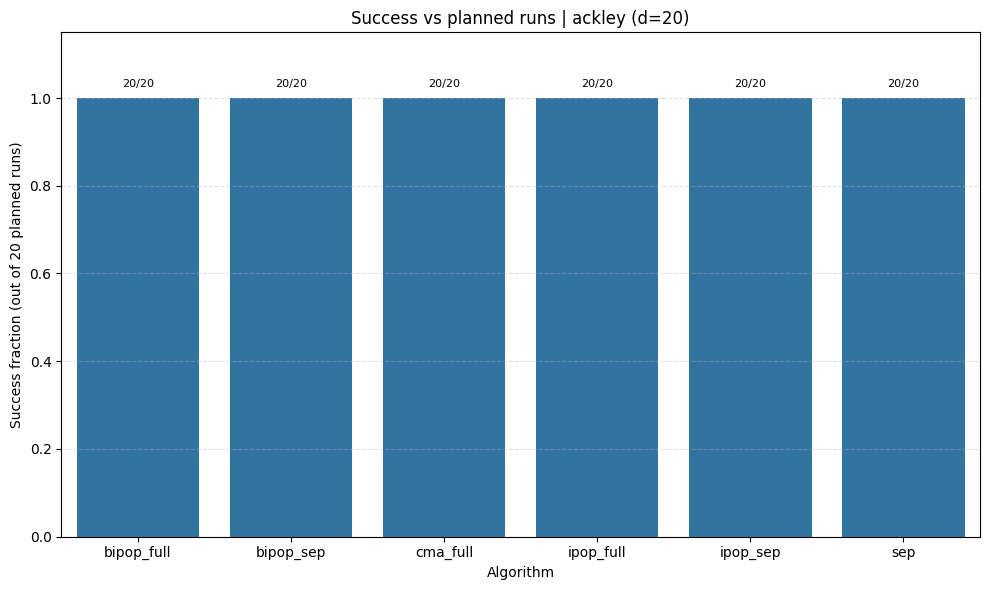

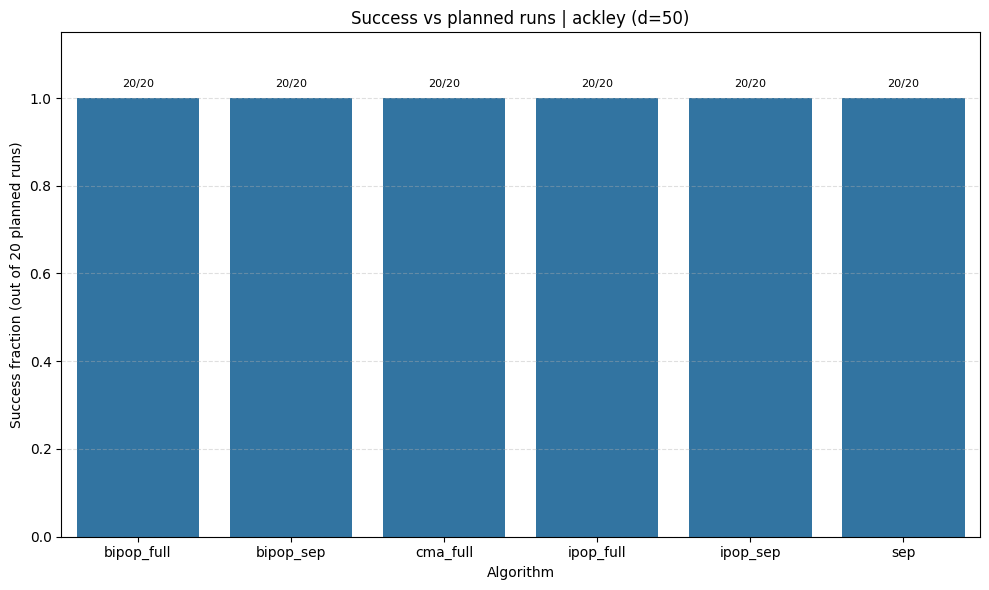

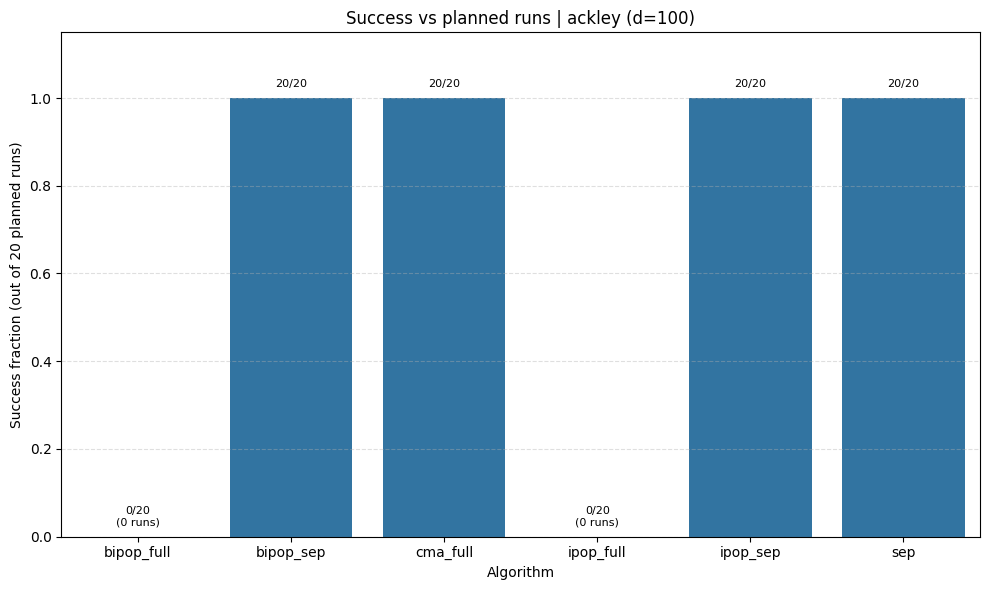

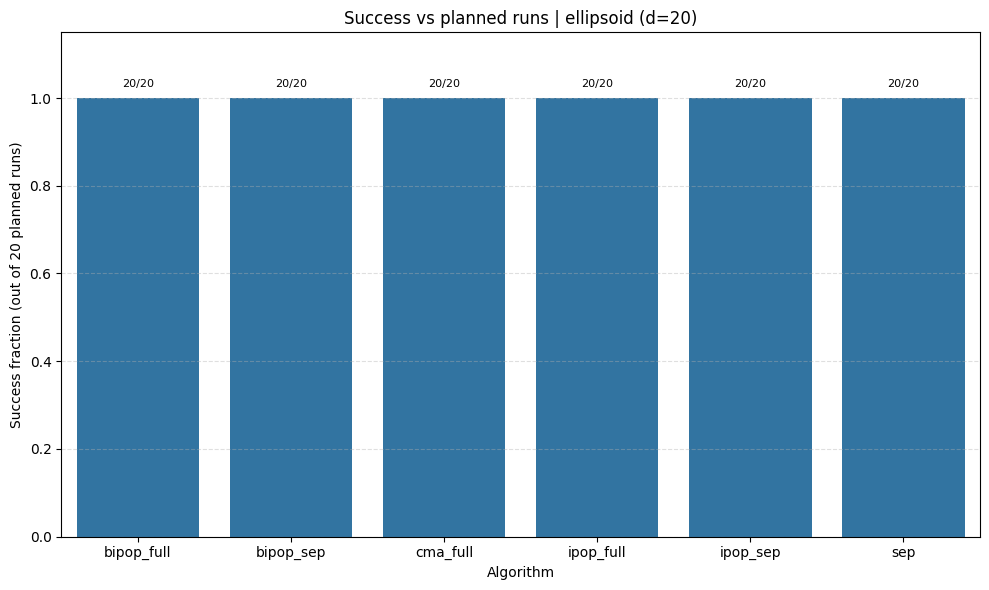

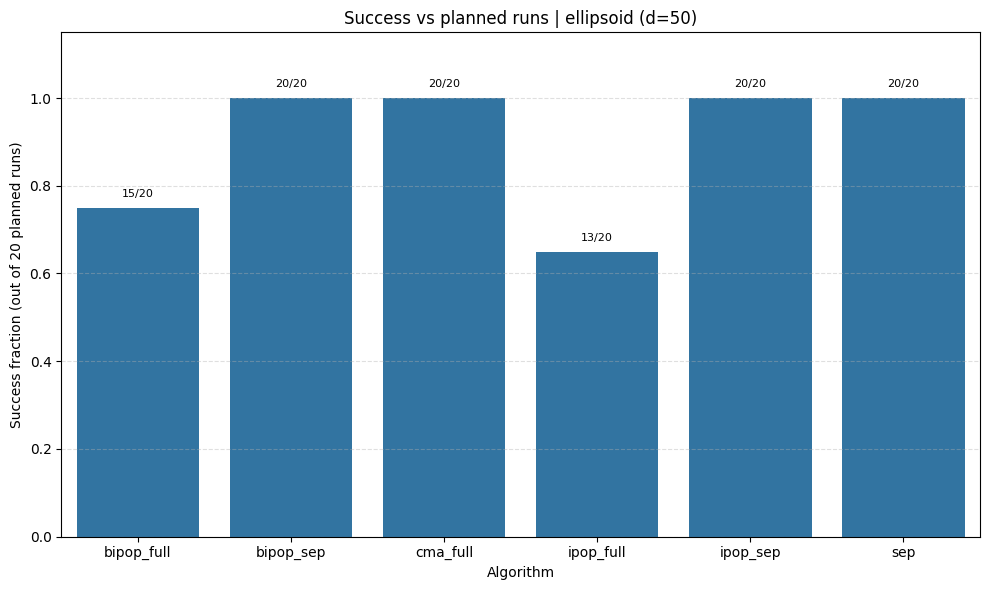

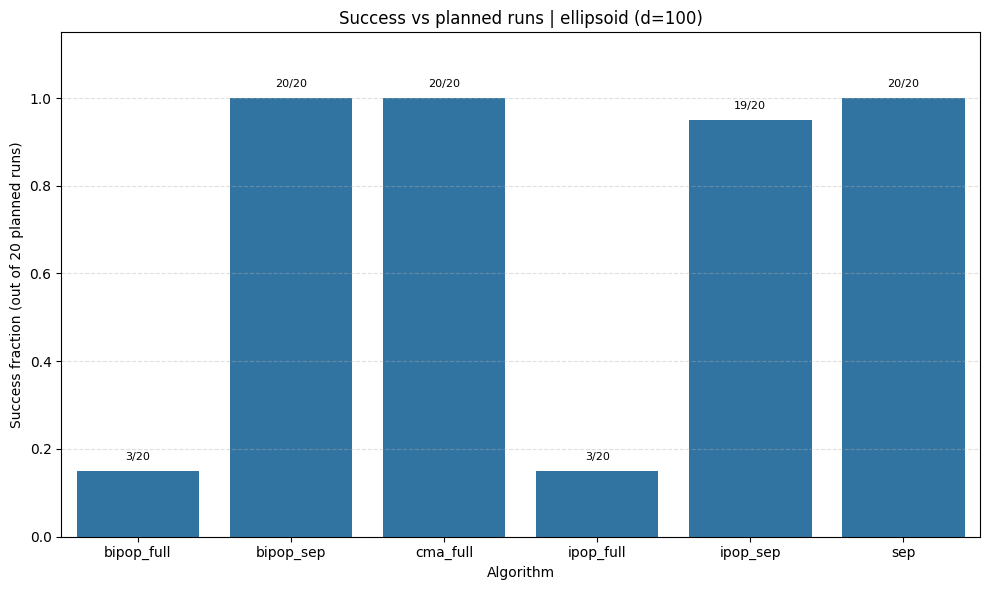

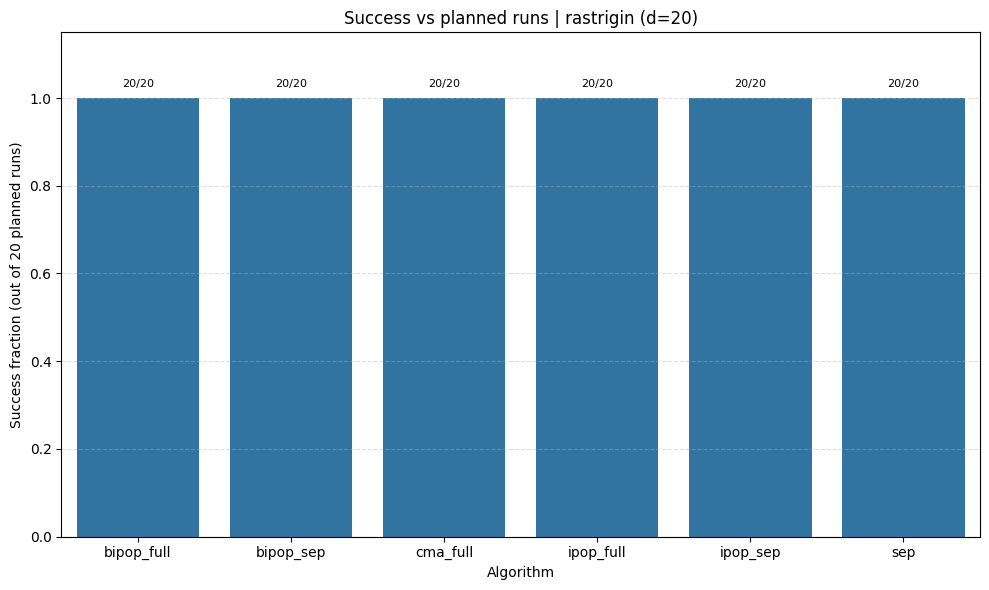

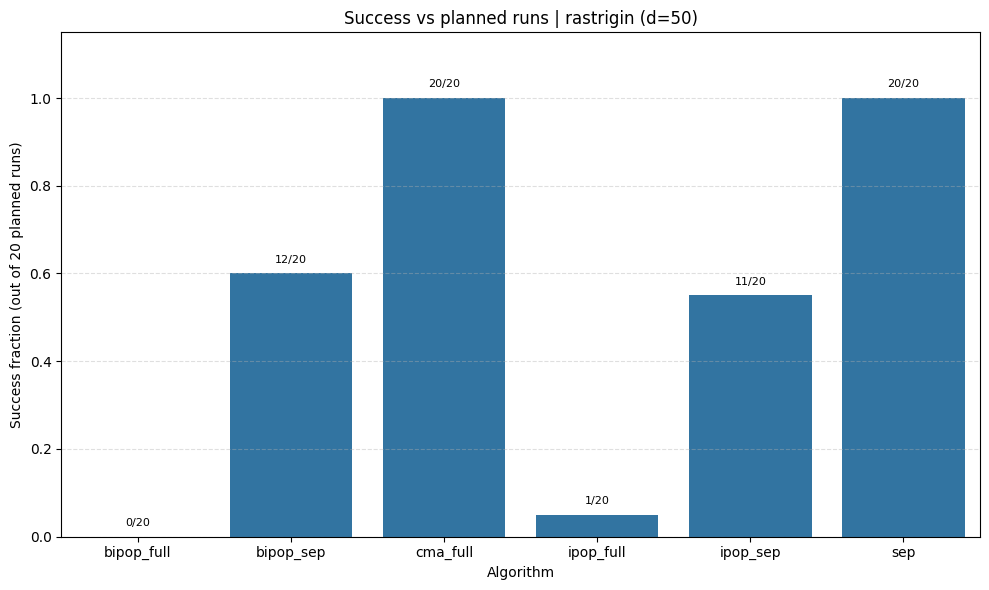

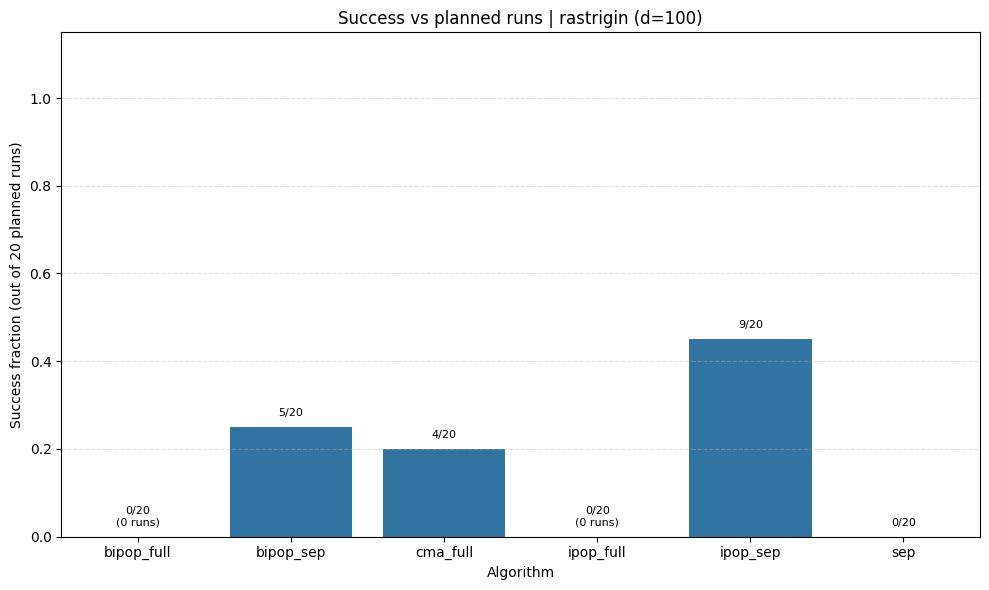

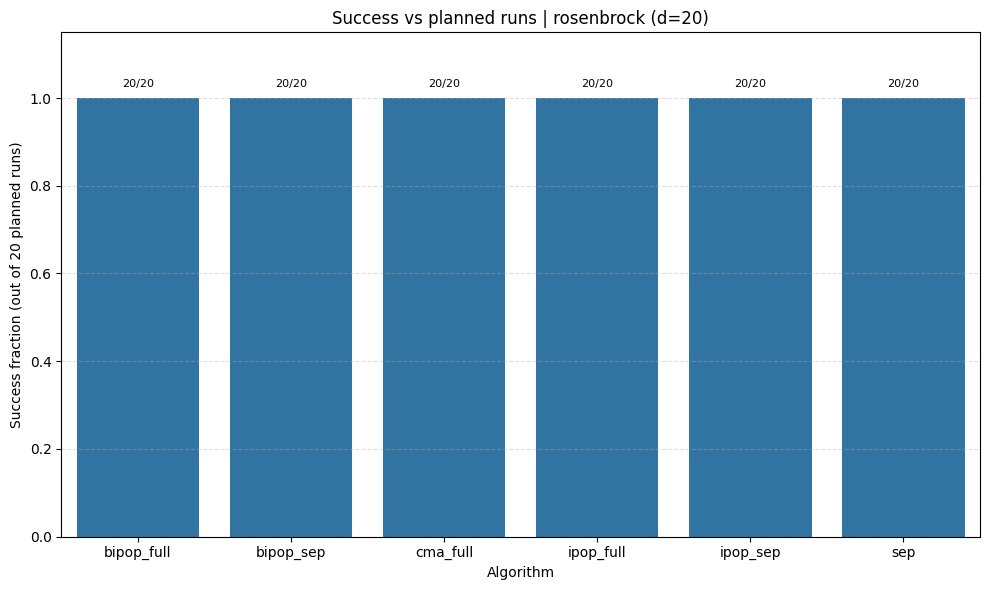

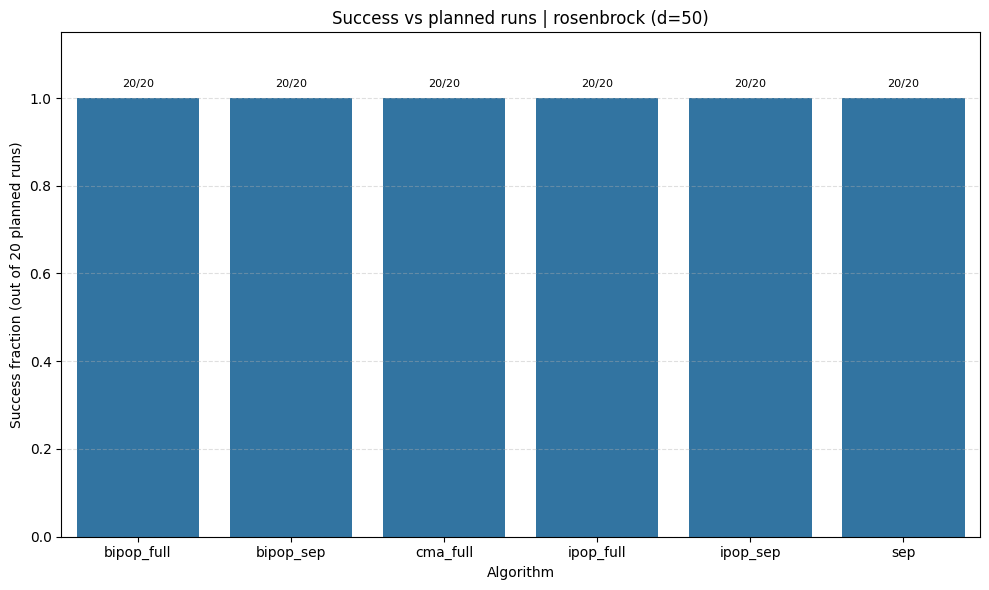

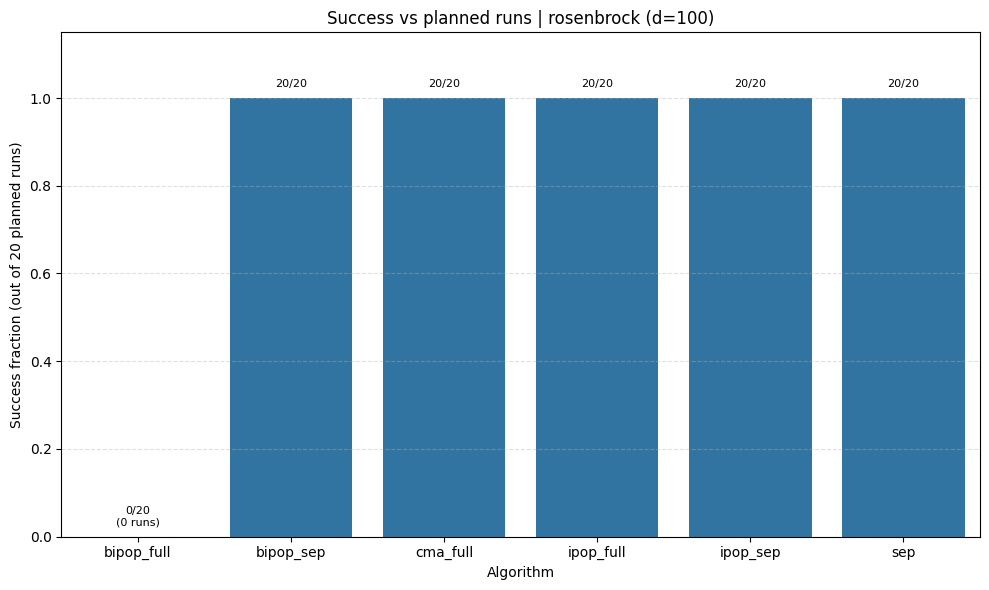

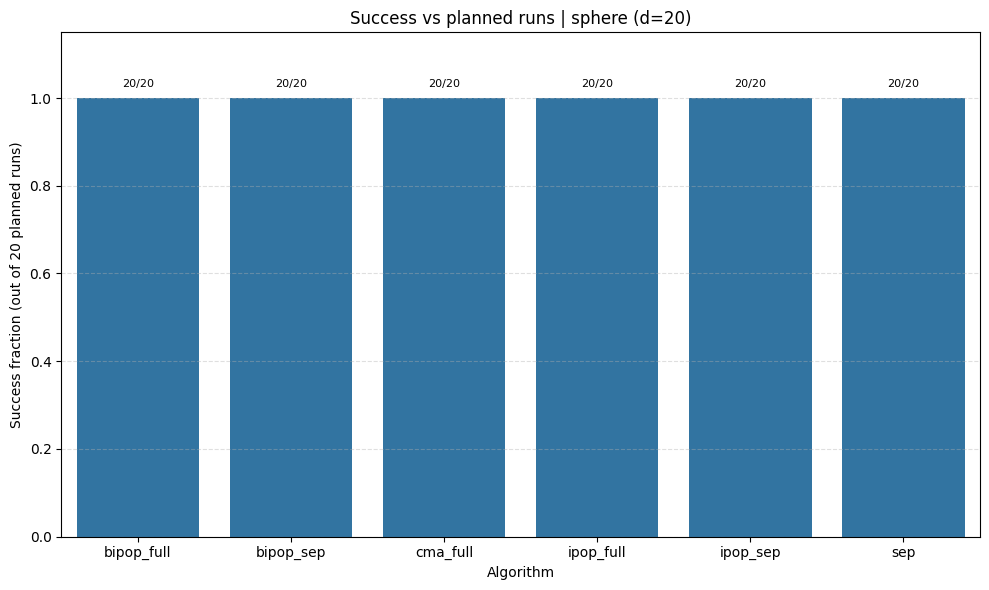

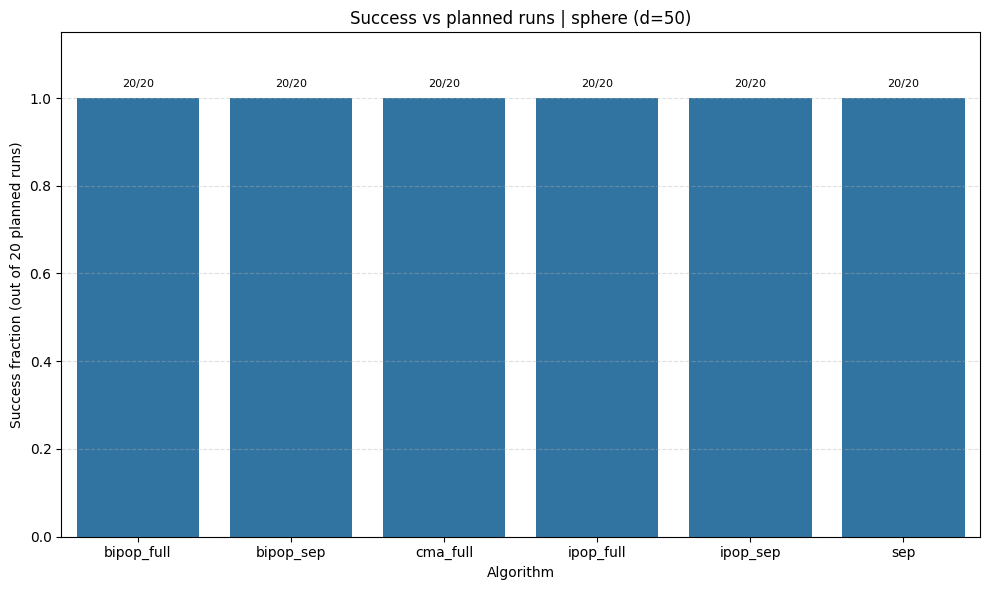

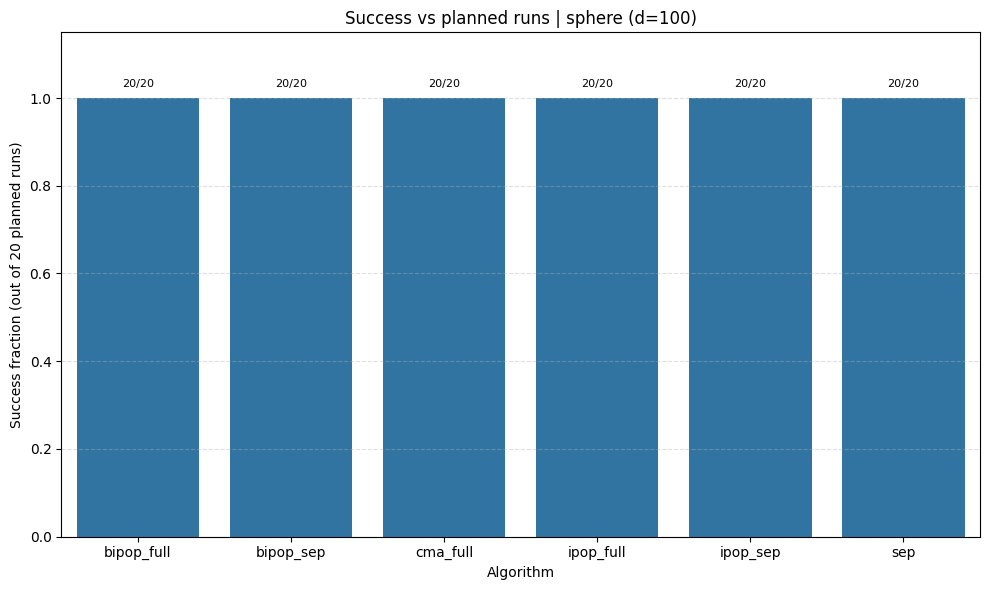

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

for func in all_funcs:
    for dim in all_dims:

        sub = agg[(agg['func'] == func) & (agg['dim'] == dim)].copy()
        sub = sub.sort_values('algo')

        plt.figure(figsize=(10, 6))
        ax = sns.barplot(
            data=sub,
            x='algo',
            y='success_rate_planned',
            order=all_algos,
            dodge=False
        )

        # Annotate "n_success/20" and, if needed, actual runs
        for i, row in sub.reset_index(drop=True).iterrows():
            label = f"{int(row['n_success'])}/{PLANNED_RUNS}"
            if row['n_runs'] != PLANNED_RUNS:
                label += f"\n({int(row['n_runs'])} runs)"
            ax.text(
                i,
                row['success_rate_planned'] + 0.02,
                label,
                ha='center',
                va='bottom',
                fontsize=8
            )

        plt.title(f"Success vs planned runs | {func} (d={dim})")
        plt.xlabel("Algorithm")
        plt.ylabel("Success fraction (out of 20 planned runs)")
        plt.ylim(0, 1.15)
        plt.grid(axis="y", ls="--", alpha=0.4)
        plt.tight_layout()
        plt.show()


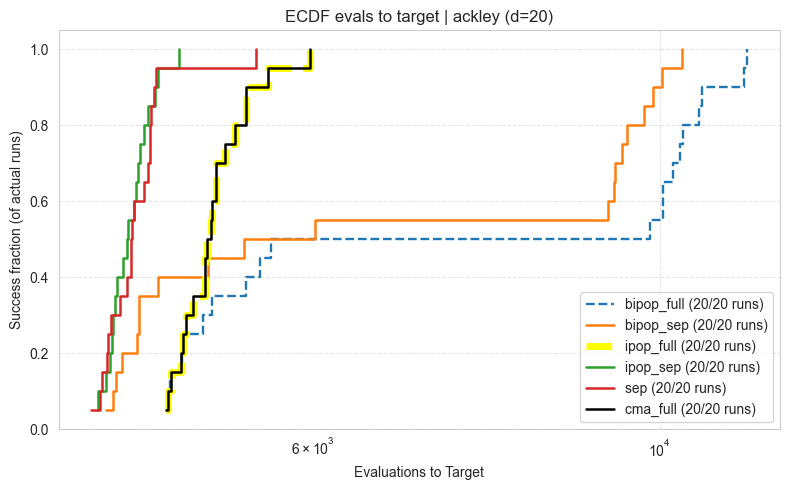

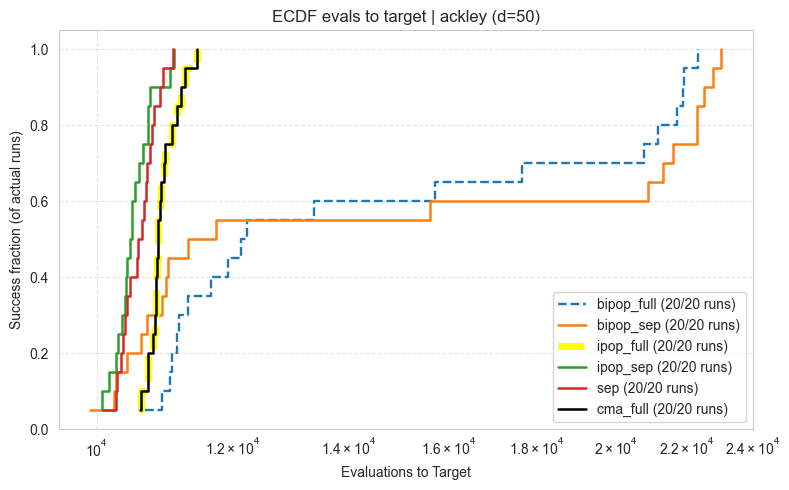

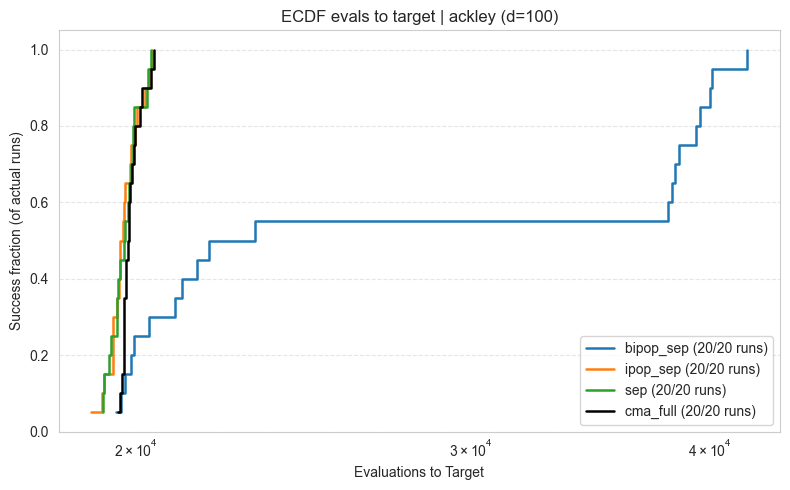

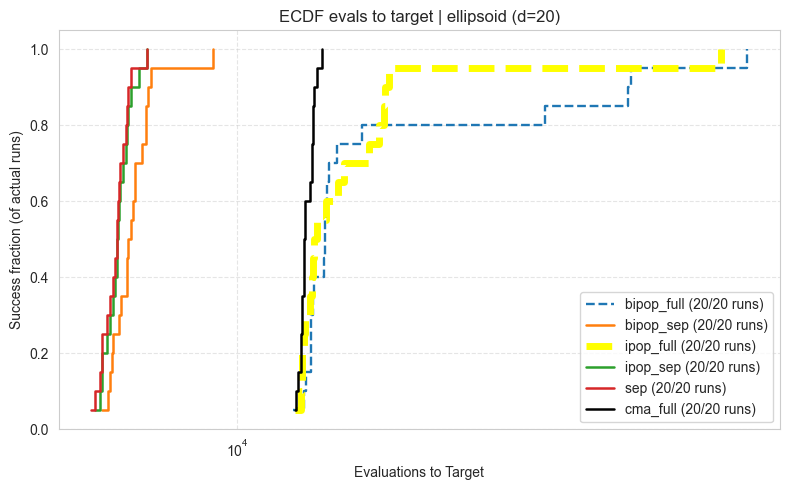

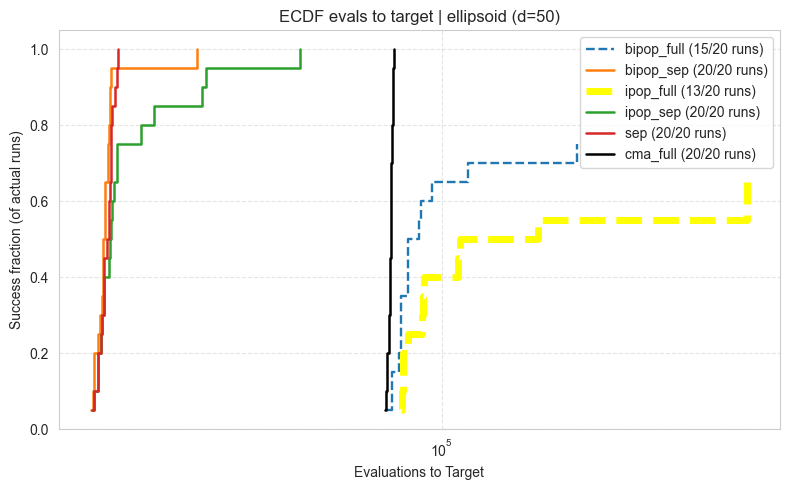

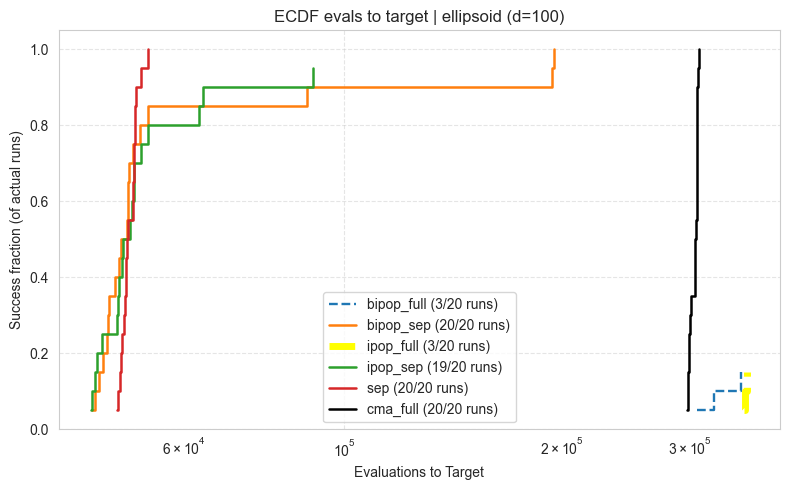

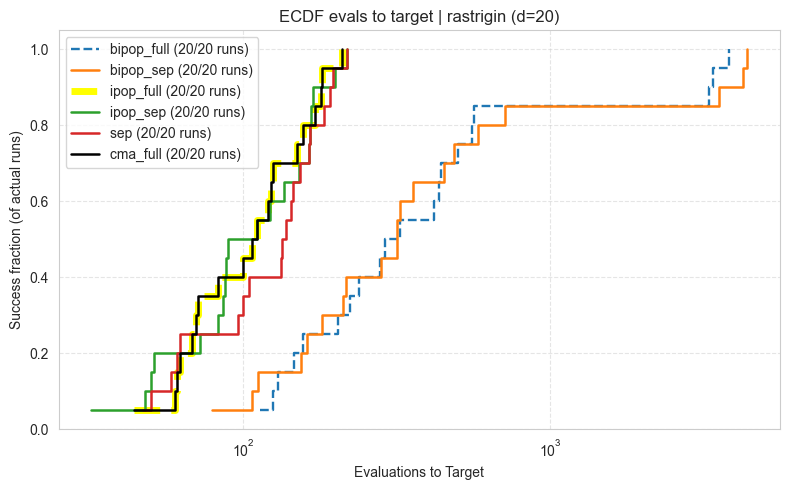

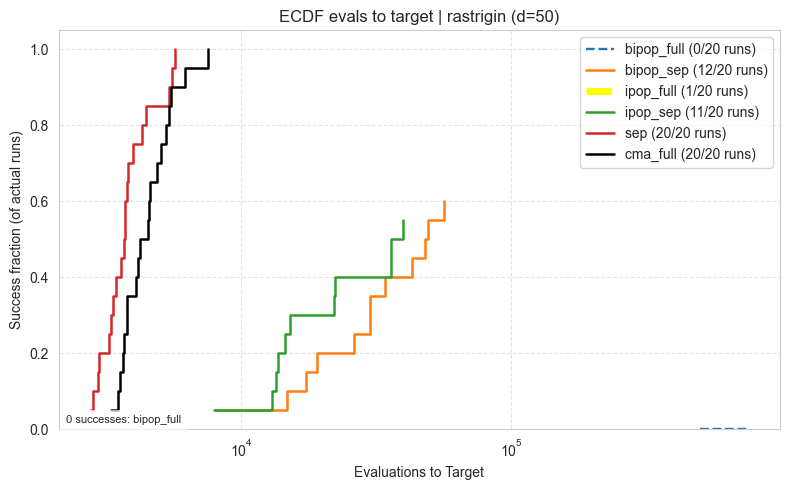

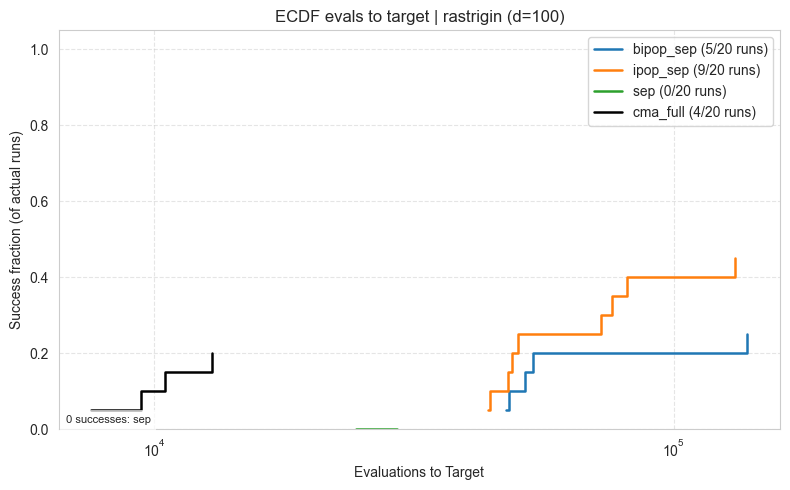

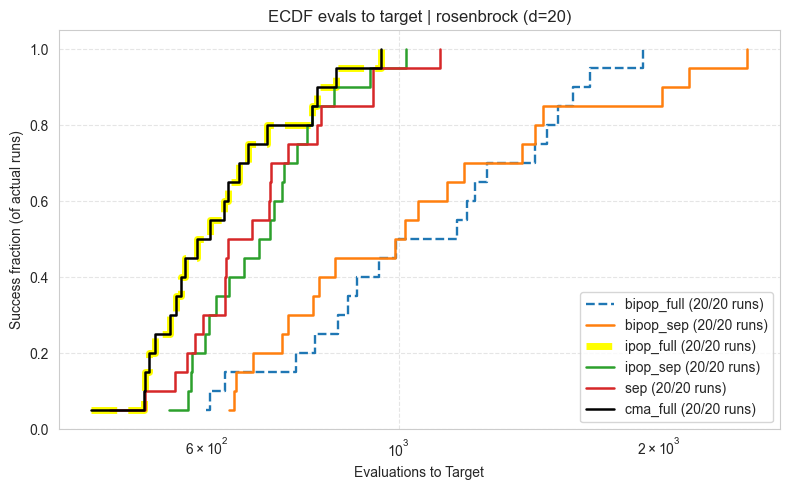

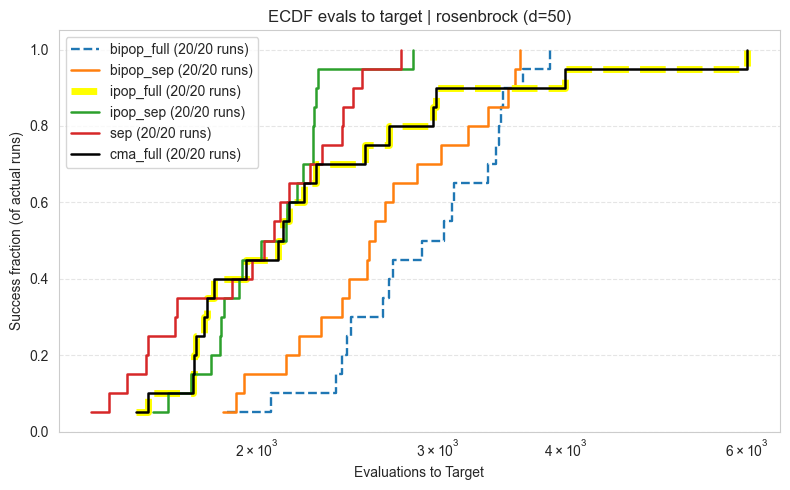

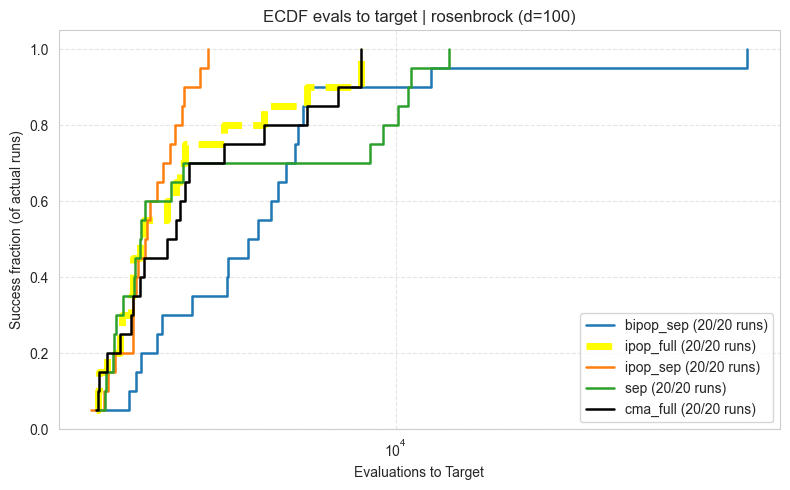

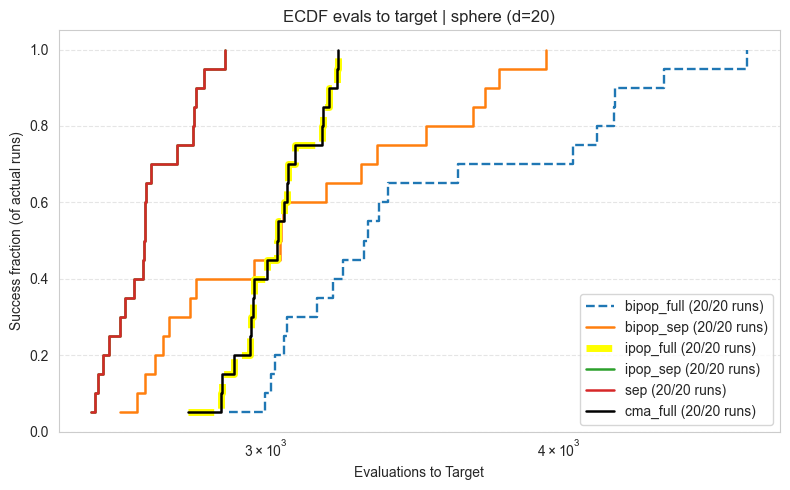

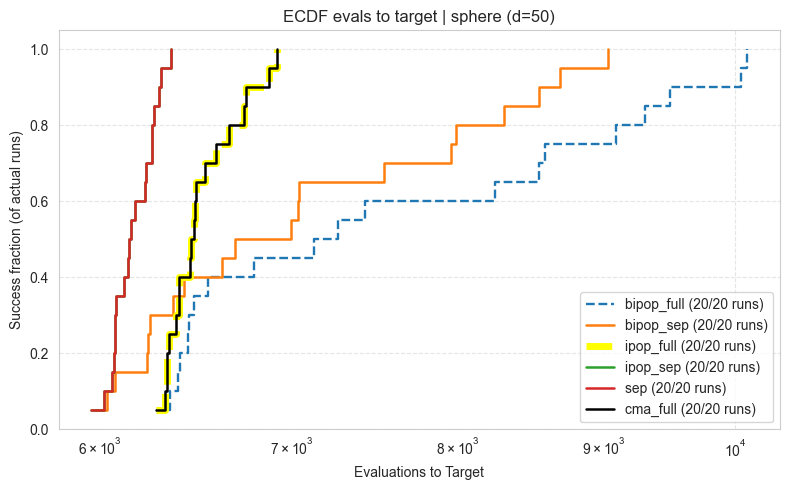

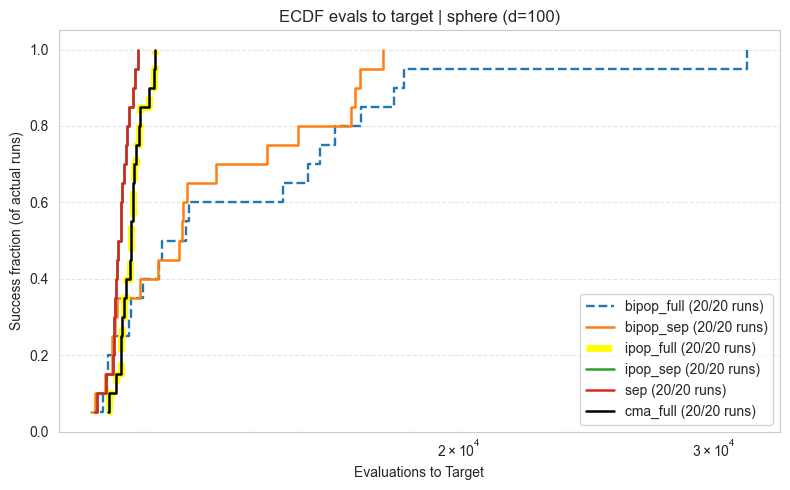

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ECDF of evaluations to target (per func × dim)
# ============================================================

# 1. Drawing order: later = plotted on top
draw_order_default = [
    "bipop_full",
    "bipop_sep",
    "ipop_full",
    "ipop_sep",
    "sep",
    "cma_full",   # draw last so it’s clearly visible
]

# 2. Visual style per algorithm (optional)
style_map = {
    "ipop_full":  dict(linestyle="--",color="yellow", linewidth=5),
    "cma_full":   dict(color="black", linewidth=1.8),
    "sep":        dict(linewidth=1.8),
    "ipop_sep":   dict(linewidth=1.8),
    "bipop_sep":  dict(linewidth=1.8),
    "bipop_full": dict(linestyle="--", linewidth=1.7),
}

for func in all_funcs:
    for dim in all_dims:

        sub = per_run[(per_run["func"] == func) & (per_run["dim"] == dim)]
        if sub.empty:
            continue

        fig, ax = plt.subplots(figsize=(8, 5))
        plotted_any = False
        no_logs_algos = []
        zero_success_algos = []

        # Algorithms actually present for this (func, dim)
        present_algos = list(sub["algo"].unique())

        # Respect preferred drawing order, but only include present algos
        algos_here = [a for a in draw_order_default if a in present_algos]
        # Add any remaining algos not in the default order
        for a in present_algos:
            if a not in algos_here:
                algos_here.append(a)

        for algo in algos_here:
            g = sub[sub["algo"] == algo]

            # No logs at all (shouldn’t normally happen if algo in present_algos)
            if g.empty:
                no_logs_algos.append(algo)
                continue

            total_runs = len(g)

            # Successful runs (hit target)
            g_succ = g[g["run_success"] == 1]
            succ_runs = len(g_succ)

            # ---------- Case A: at least one successful run ----------
            if succ_runs > 0:
                # Prefer evals_to_target, fallback to evals_final if necessary
                x_raw = g_succ["evals_to_target"]
                if x_raw.notna().any():
                    x = np.sort(x_raw.dropna().astype(float).values)
                else:
                    x = np.sort(g_succ["evals_final"].dropna().astype(float).values)

                # Log-scale safety: replace non-positive with 1 evaluation
                x = np.where(x <= 0, 1.0, x)

                if len(x) == 0:
                    zero_success_algos.append(algo)
                else:
                    y = np.arange(1, len(x) + 1) / total_runs

                    style = style_map.get(algo, {})
                    ax.step(
                        x,
                        y,
                        where="post",
                        label=f"{algo} ({succ_runs}/{total_runs} runs)",
                        **style,
                    )
                    plotted_any = True

            # ---------- Case B: ran but 0 successful runs ----------
            if succ_runs == 0:
                zero_success_algos.append(algo)
                max_evals = g["evals_final"].max()
                min_evals = g["evals_final"].min()

                if pd.notna(max_evals) and max_evals > 0:
                    if (not pd.notna(min_evals)) or (min_evals <= 0):
                        min_evals = 1.0
                    if min_evals >= max_evals:
                        max_evals = min_evals * 1.5

                    style = style_map.get(algo, {})
                    ax.step(
                        [min_evals, max_evals],
                        [0.0, 0.0],
                        where="post",
                        label=f"{algo} (0/{total_runs} runs)",
                        **style,
                    )
                    plotted_any = True

        # ---------- Axes formatting ----------
        ax.set_title(f"ECDF evals to target | {func} (d={dim})")
        ax.set_xlabel("Evaluations to Target")
        ax.set_ylabel("Success fraction (of actual runs)")
        ax.set_xscale("log")
        ax.set_ylim(0, 1.05)
        ax.grid(True, ls="--", alpha=0.5)

        if plotted_any:
            ax.legend()
        else:
            ax.text(
                0.5,
                0.5,
                "No data / no successful runs for any algorithm",
                ha="center",
                va="center",
                fontsize=11,
                transform=ax.transAxes,
            )

        # ---------- Info box: 0-success + no-logs ----------
        info_lines = []
        if zero_success_algos:
            info_lines.append("0 successes: " + ", ".join(zero_success_algos))
        if no_logs_algos:
            info_lines.append("No logs: " + ", ".join(no_logs_algos))

        if info_lines:
            ax.text(
                0.01,
                0.01,
                "\n".join(info_lines),
                ha="left",
                va="bottom",
                fontsize=8,
                transform=ax.transAxes,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
            )

        plt.tight_layout()
        plt.show()


In [7]:
from scipy.stats import friedmanchisquare

def friedman_test_per_run(per_run, func, dim,
                          value_col='best_fitness',
                          min_algos=3, min_seeds=2):
    """
    Run a Friedman test to compare algorithms on a given (func, dim)
    using per-run performance (e.g. best_fitness).

    per_run: DataFrame with columns ['func', 'dim', 'algo', 'seed', value_col, ...]
    func:    benchmark function name (e.g. 'sphere')
    dim:     dimension (e.g. 20, 50, 100)
    value_col: which column in per_run to compare (default 'best_fitness')
    """

    # Filter to the function and dimension of interest
    subset = per_run[(per_run['func'] == func) & (per_run['dim'] == dim)]

    if subset.empty:
        print(f"No runs for {func} d={dim}")
        return

    # Pivot: rows = seeds (blocks), columns = algorithms, values = performance
    pivot = subset.pivot(index='seed', columns='algo', values=value_col)

    # Keep only seeds where *all* algorithms have results (no missing values)
    pivot = pivot.dropna(axis=0, how='any')

    n_seeds, n_algos = pivot.shape

    if n_algos < min_algos or n_seeds < min_seeds:
        print(f"Not enough data for Friedman: {func} d={dim} "
              f"(seeds={n_seeds}, algos={n_algos})")
        return

    # Friedman test expects one array per algorithm (paired across seeds)
    algo_series = [pivot[c].values for c in pivot.columns]

    stat, p = friedmanchisquare(*algo_series)

    print(
        f"Friedman test on {value_col} | {func} d={dim} "
        f"(seeds={n_seeds}, algos={n_algos}): "
        f"chi2={stat:.2f}, p={p:.3g}"
    )


# Run the test for all function–dimension combinations that appear in per_run
for func in sorted(per_run['func'].unique()):
    for dim in sorted(per_run['dim'].unique()):
        friedman_test_per_run(per_run, func, dim)


Friedman test on best_fitness | ackley d=20 (seeds=20, algos=6): chi2=22.12, p=0.000497
Friedman test on best_fitness | ackley d=50 (seeds=20, algos=6): chi2=41.59, p=7.14e-08
Friedman test on best_fitness | ackley d=100 (seeds=20, algos=4): chi2=26.70, p=6.8e-06
Friedman test on best_fitness | ellipsoid d=20 (seeds=20, algos=6): chi2=63.46, p=2.33e-12
Friedman test on best_fitness | ellipsoid d=50 (seeds=20, algos=6): chi2=64.91, p=1.17e-12
Friedman test on best_fitness | ellipsoid d=100 (seeds=20, algos=6): chi2=83.89, p=1.29e-16
Friedman test on best_fitness | rastrigin d=20 (seeds=20, algos=6): chi2=41.30, p=8.16e-08
Friedman test on best_fitness | rastrigin d=50 (seeds=20, algos=6): chi2=23.77, p=0.00024
Friedman test on best_fitness | rastrigin d=100 (seeds=20, algos=4): chi2=6.24, p=0.1
Friedman test on best_fitness | rosenbrock d=20 (seeds=20, algos=6): chi2=51.76, p=6.04e-10
Friedman test on best_fitness | rosenbrock d=50 (seeds=20, algos=6): chi2=52.58, p=4.1e-10
Friedman tes

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


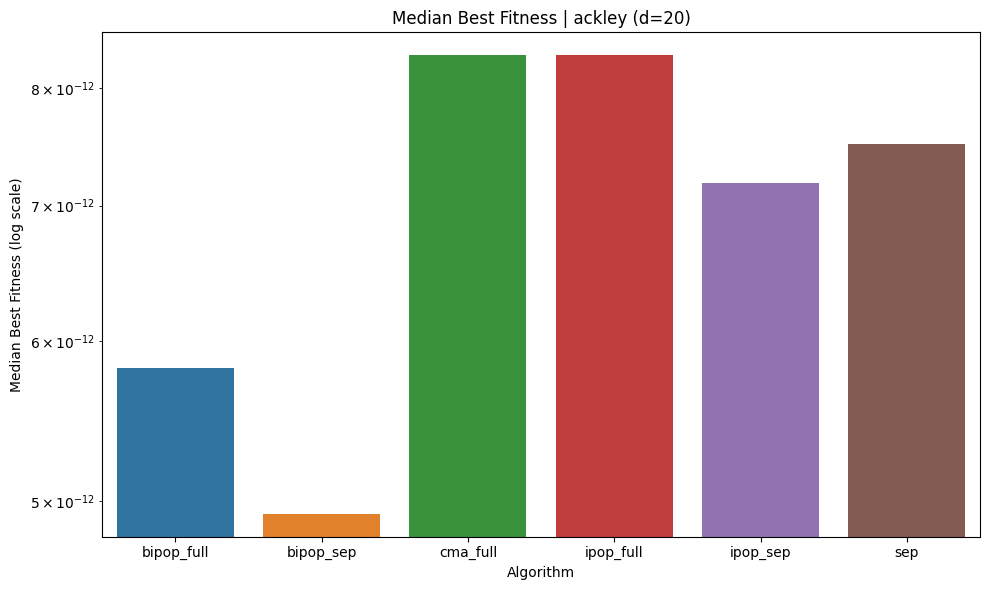

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


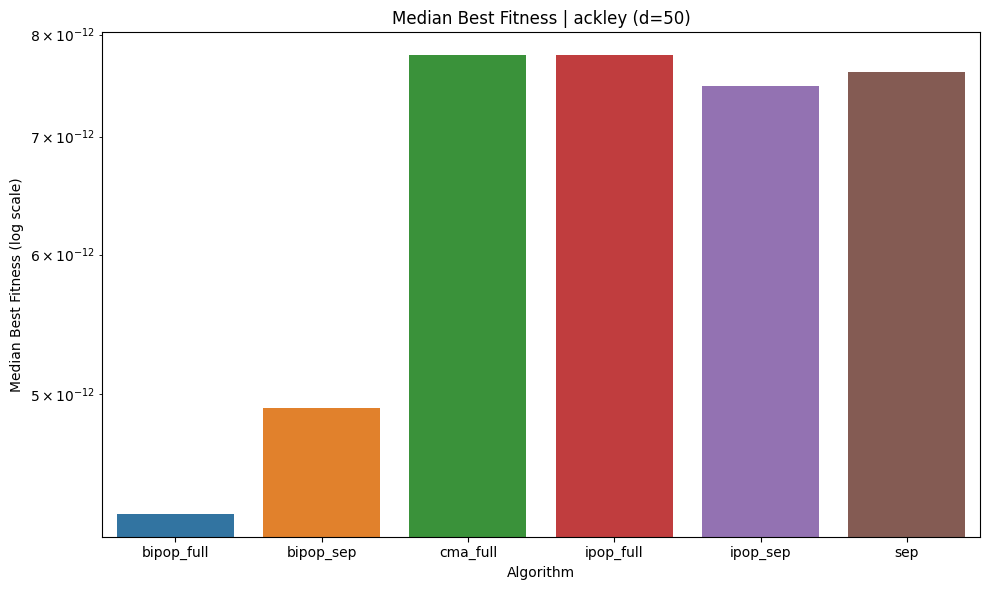

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


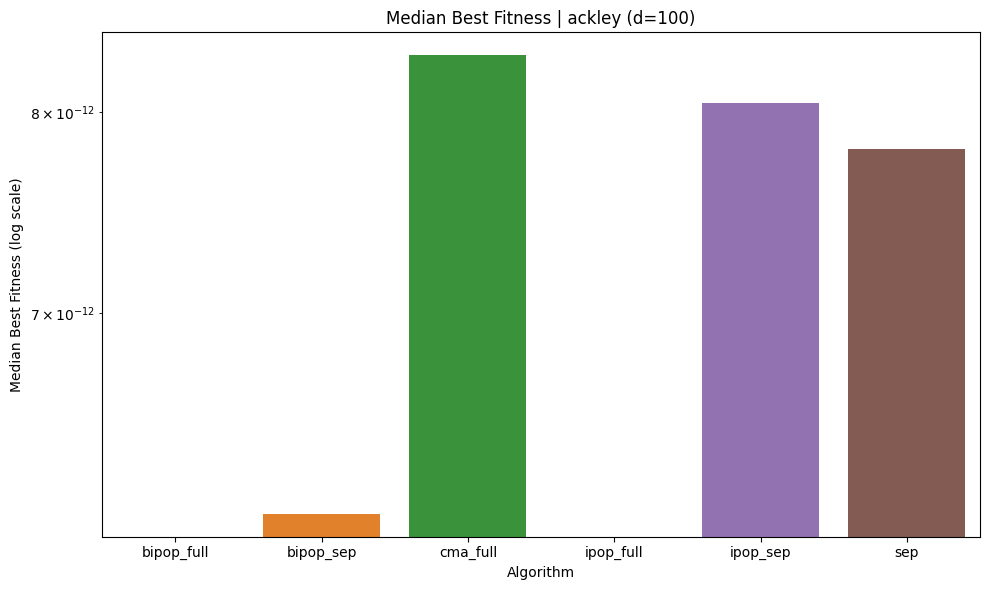

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


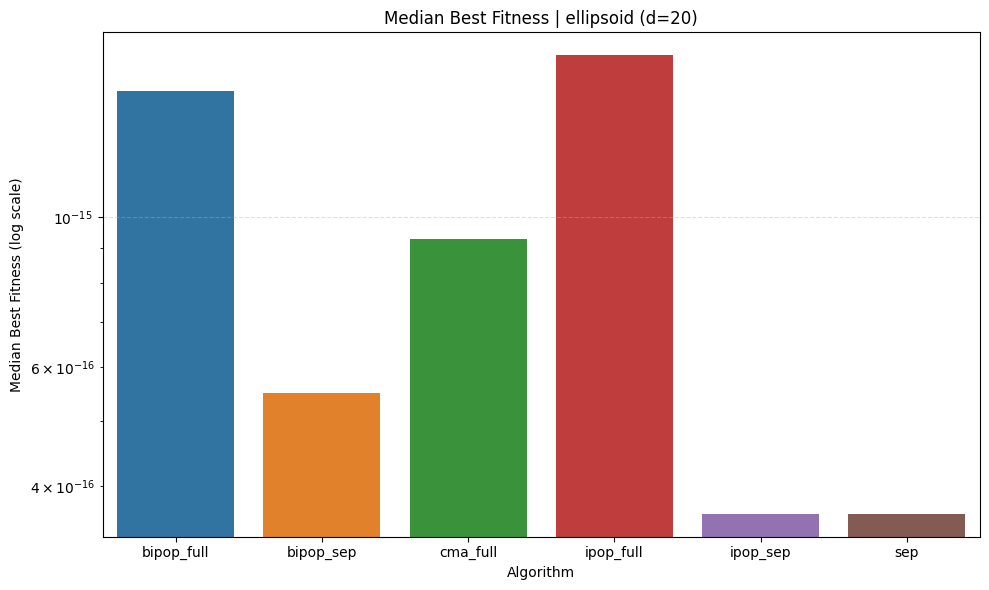

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


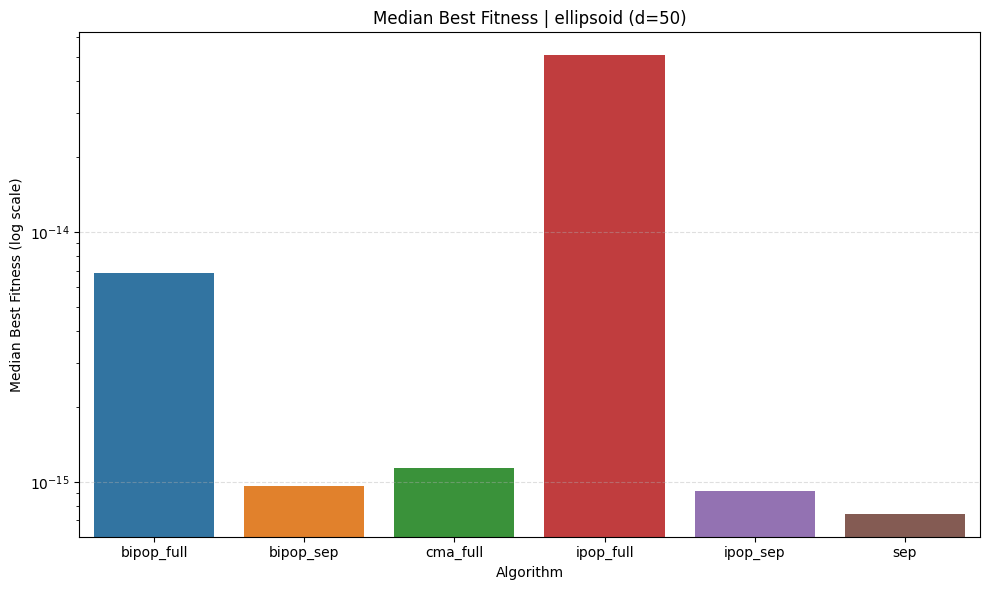

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


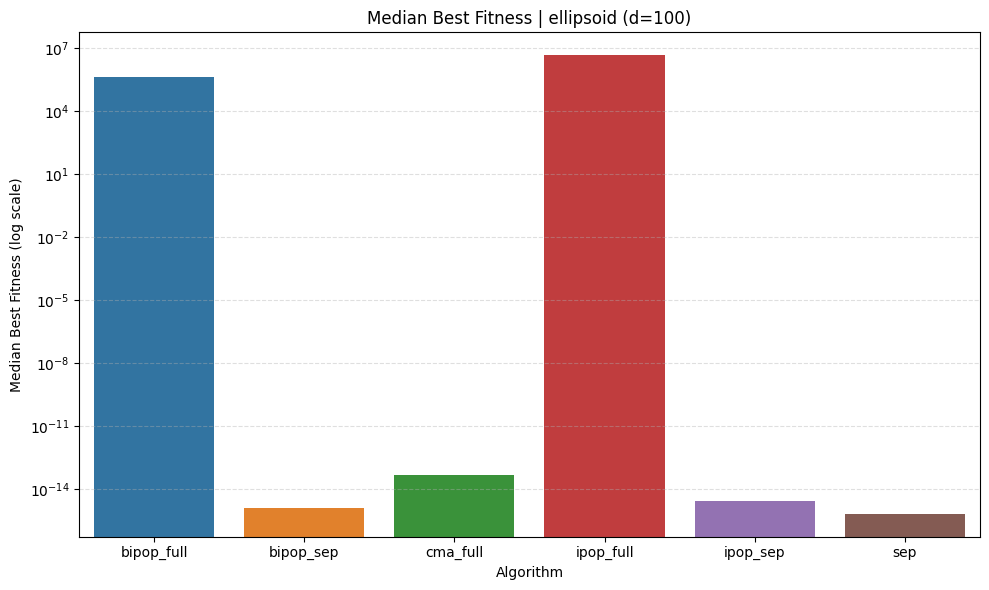

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


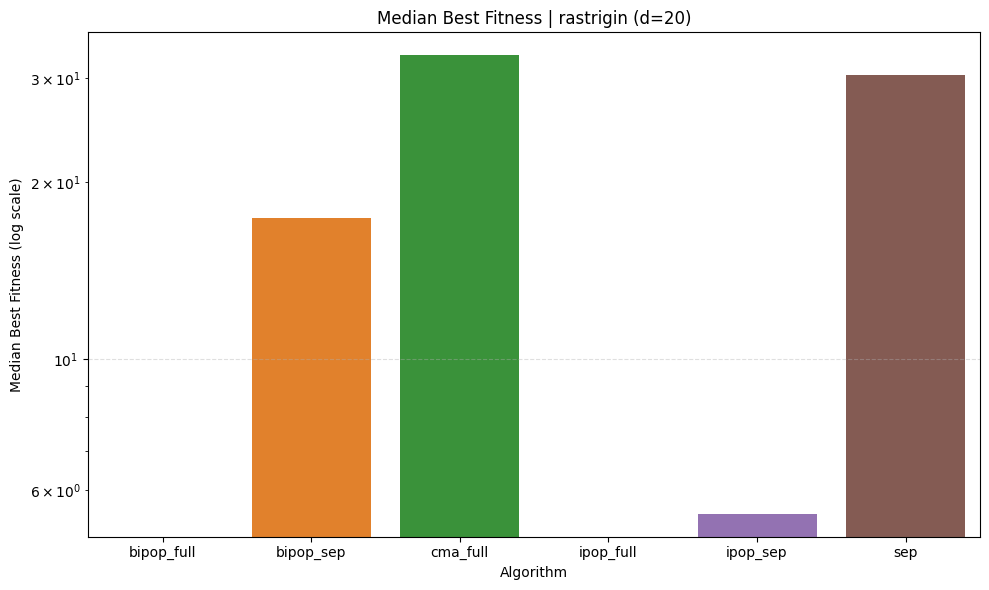

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


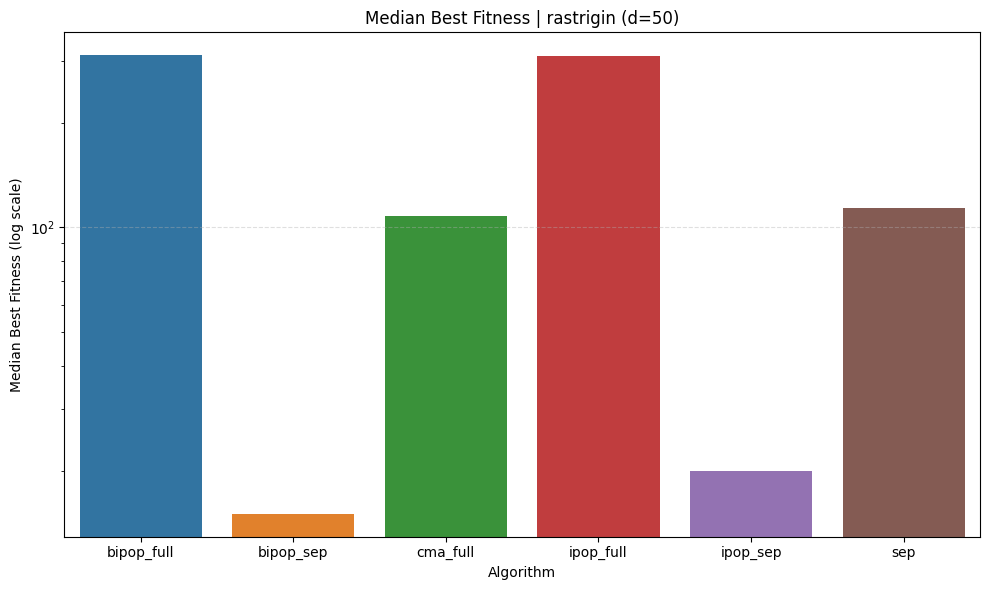

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


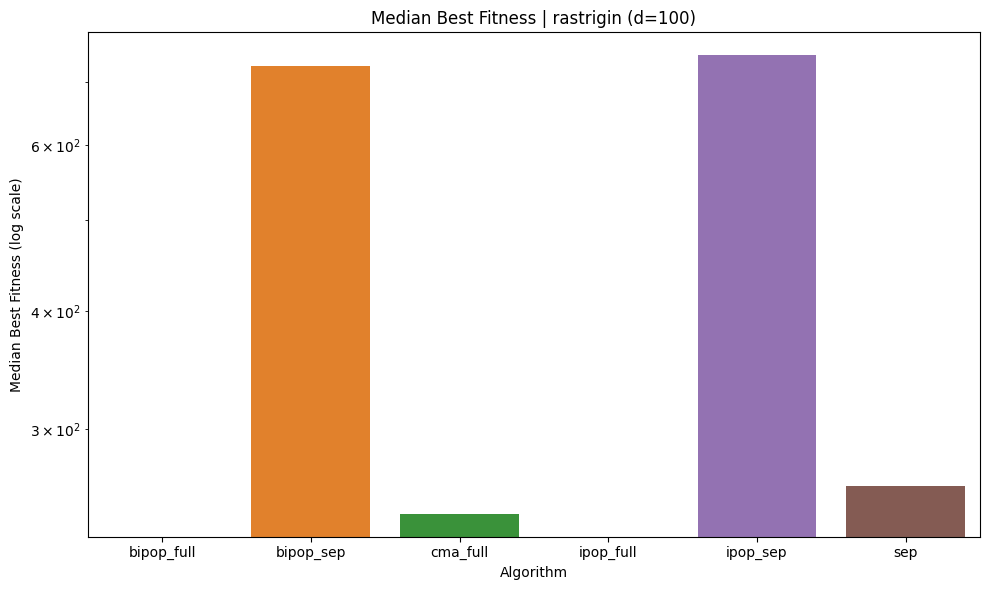

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


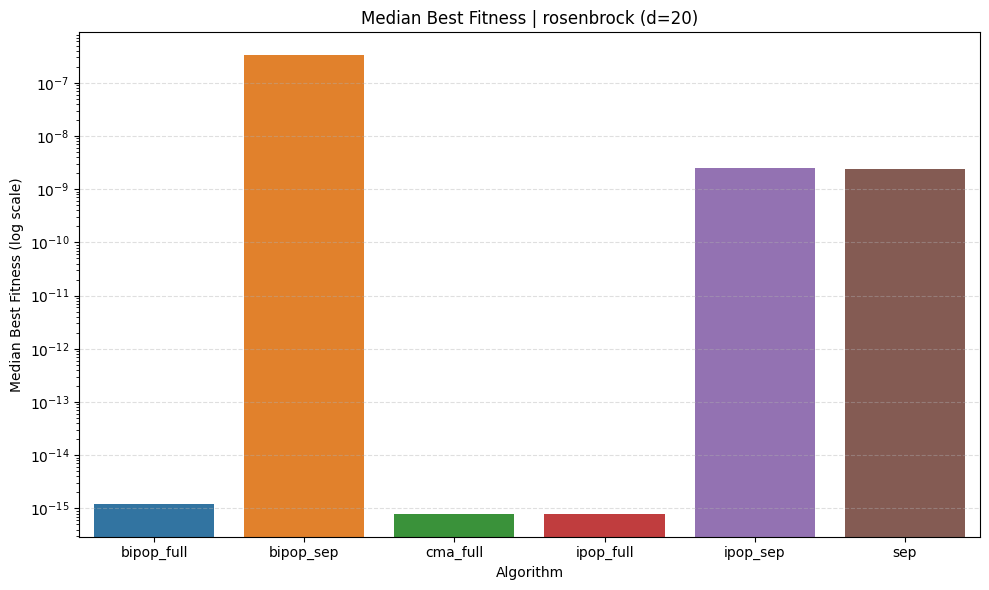

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


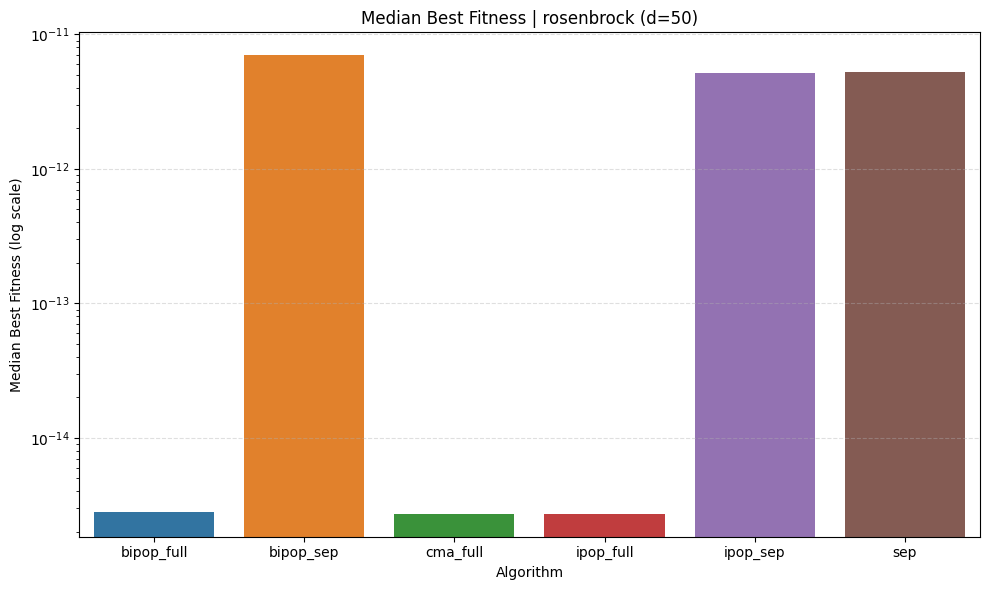

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


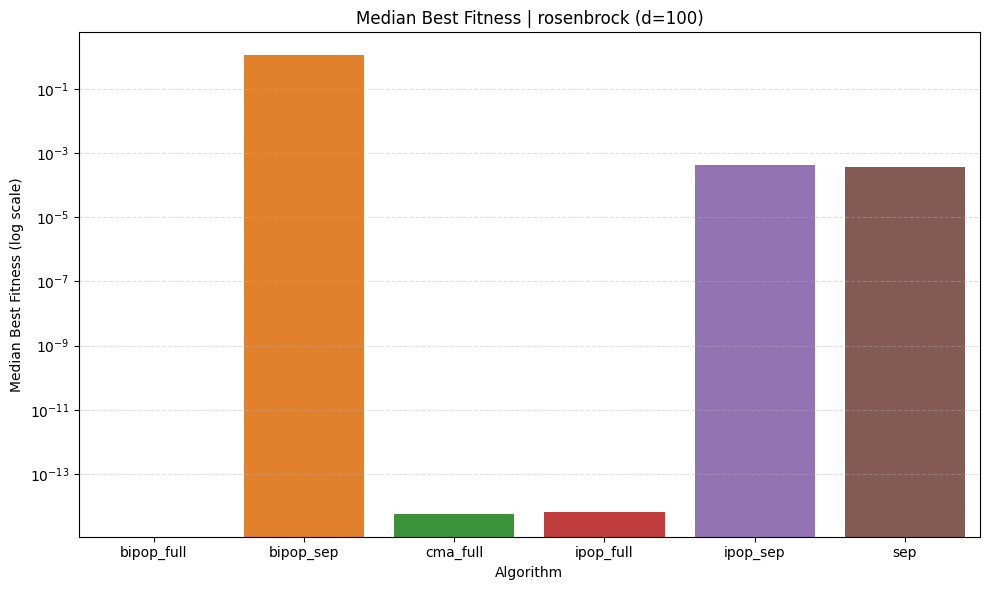

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


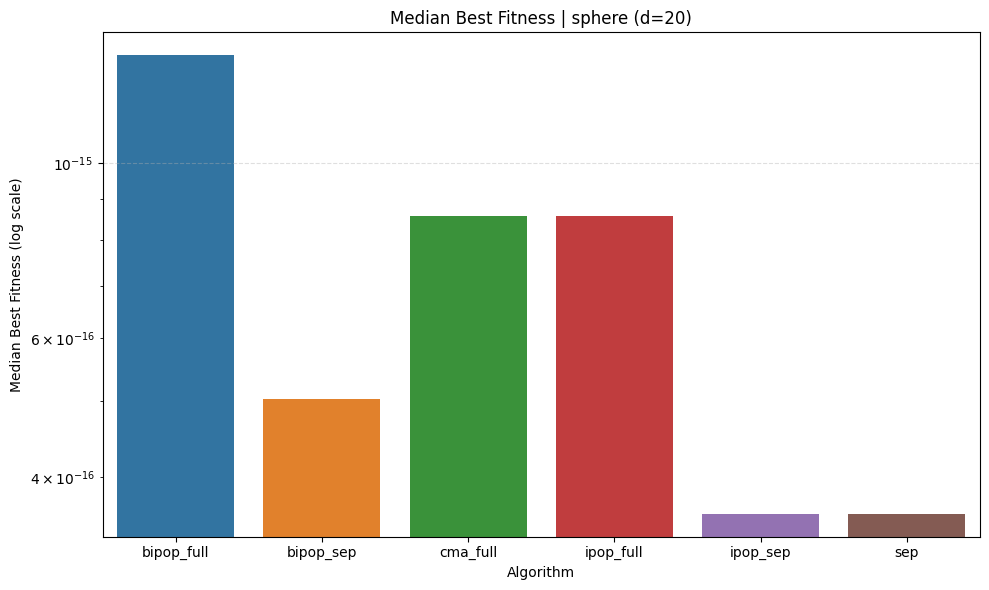

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


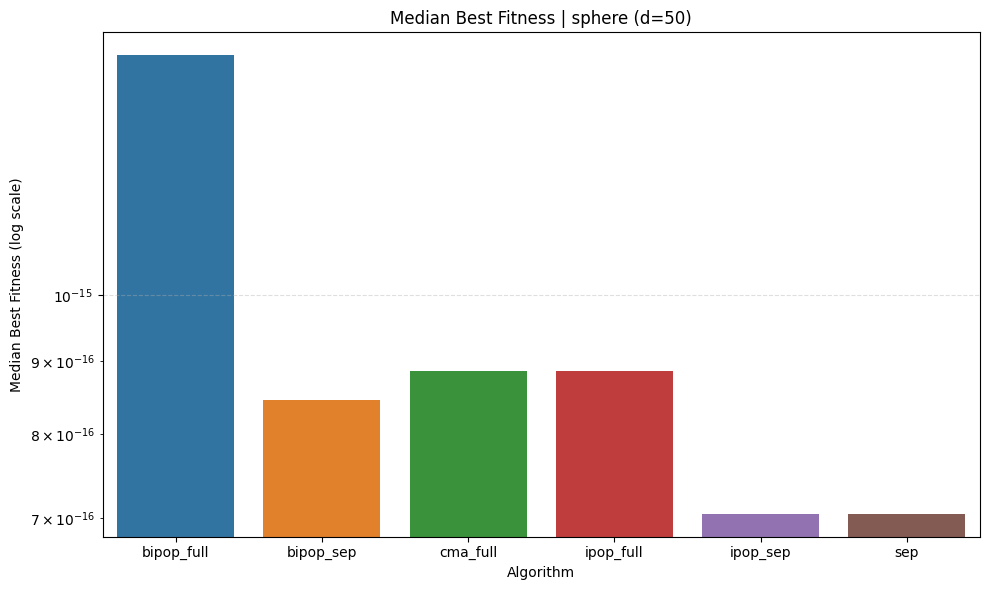

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\2114040086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


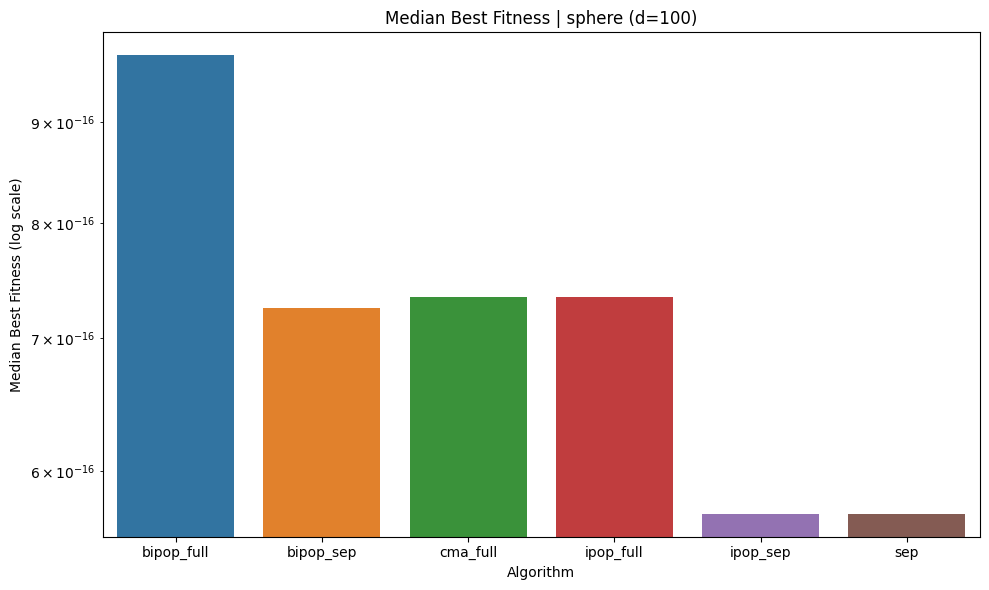

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

all_funcs = agg['func'].unique()
all_dims = sorted(agg['dim'].unique())
all_algos = sorted(agg['algo'].unique())

for func in all_funcs:
    for dim in all_dims:

        sub = agg[(agg['func']==func) & (agg['dim']==dim)]

        full = pd.DataFrame({
            "func": func,
            "dim": dim,
            "algo": all_algos
        })

        merged = full.merge(sub, on=["func", "dim", "algo"], how="left")

        # Uncomment if missing should be 0:
        # merged['median_best'] = merged['median_best'].fillna(0)

        plt.figure(figsize=(10,6))
        sns.barplot(
            data=merged,
            x='algo',
            y='median_best',
            hue=None,
            palette="tab10",
            dodge=False
        )

        plt.yscale('log')
        plt.title(f'Median Best Fitness | {func} (d={dim})')
        plt.xlabel('Algorithm')
        plt.ylabel('Median Best Fitness (log scale)')
        plt.grid(axis='y', ls='--', alpha=0.4)
        plt.tight_layout()
        plt.show()


In [9]:
# We first restrict to (func, dim, algo) combos that actually have runs.
# Rows where n_runs == 0 are just "design grid" placeholders (no logs),
# so including them would only add NaNs and noise.
agg_valid = agg[agg['n_runs'] > 0].copy()

# ------------------------------------------------------------------
# Pivot tables for per-algorithm comparison:
# - Rows:    (func, dim) pairs
# - Columns: algorithms
# - Values:  mean_best / median_best across runs
#
# Why both?
# - mean_best:
#     * Uses the arithmetic mean of best fitness over runs.
#     * Sensitive to outliers (a few very bad runs can pull it up).
#     * Still useful to see the "average" behaviour including rare failures.
#
# - median_best:
#     * Uses the median of best fitness over runs.
#     * Much more robust to outliers and heavy tails.
#     * Good proxy for "typical" performance of an algorithm.
#
# How this helps:
# - For each (func, dim), you can scan across the row and see
#   which algorithm has the lowest mean/median best fitness.
# - If one algorithm has the lowest (or near-lowest) median_best
#   consistently across dimensions for a function, it is a strong
#   candidate for "best" on that function.
# - Differences between mean_best and median_best can also flag
#   instability: if mean >> median, the algorithm occasionally
#   has very bad runs (heavy tails / reliability issues).
# ------------------------------------------------------------------

pivot_mean = agg_valid.pivot_table(
    index=['func', 'dim'],
    columns='algo',
    values='mean_best'
)

pivot_median = agg_valid.pivot_table(
    index=['func', 'dim'],
    columns='algo',
    values='median_best'
)

print("Mean of Best Fitness (lower is better, but sensitive to outliers):")
display(pivot_mean)

print("Median of Best Fitness (lower is better, robust to outliers):")
display(pivot_median)


Mean of Best Fitness (lower is better, but sensitive to outliers):


algo              bipop_full     bipop_sep      cma_full     ipop_full  \
func       dim                                                           
ackley     20   5.717649e-12  5.055778e-12  9.468071e-12  9.468071e-12   
           50   4.199752e-12  4.215917e-12  7.662049e-12  7.662049e-12   
           100           NaN  5.209078e-12  8.473311e-12           NaN   
ellipsoid  20   3.667005e-15  6.495866e-16  1.025570e-15  2.755223e-15   
           50   5.250040e+03  1.544560e-15  1.155713e-15  3.896487e+03   
           100  5.115912e+05  9.725258e-15  4.349563e-13  4.177286e+06   
rastrigin  20   1.156696e+01  4.898877e+01  3.412704e+01  1.346489e+01   
           50   3.100964e+02  1.451282e+02  1.049680e+02  2.976788e+02   
           100           NaN  5.666639e+02  2.353570e+02           NaN   
rosenbrock 20   2.672150e-01  2.132516e-01  3.986624e-01  3.986624e-01   
           50   5.979936e-01  5.979936e-01  1.993312e-01  2.178333e+00   
           100           NaN  1.083969e+01  5.479691e-15  1.877040e+01   
sphere     20   1.622323e-15  6.283182e-16  1.042195e-15  1.042195e-15   
           50   1.799751e-15  9.400069e-16  9.570617e-16  9.570617e-16   
           100  1.265847e-15  1.045328e-15  7.654669e-16  7.654669e-16   

algo                ipop_sep           sep  
func       dim                              
ackley     20   8.001511e-12  8.750778e-12  
           50   7.658141e-12  7.758150e-12  
           100  8.039880e-12  7.979839e-12  
ellipsoid  20   4.438470e-16  4.371003e-16  
           50   2.247433e-15  7.447734e-16  
           100  2.690968e+04  6.806971e-16  
rastrigin  20   1.885142e+01  3.556972e+01  
           50   1.631386e+02  1.132758e+02  
           100  4.385198e+02  2.649072e+02  
rosenbrock 20   3.986624e-01  5.979936e-01  
           50   5.987446e-01  7.973248e-01  
           100  9.469880e+00  5.983737e-01  
sphere     20   4.324753e-16  4.324753e-16  
           50   7.862020e-16  7.862020e-16  
           100  6.512387e-16  6.512387e-16

Median of Best Fitness (lower is better, robust to outliers):


algo              bipop_full     bipop_sep      cma_full     ipop_full  \
func       dim                                                           
ackley     20   5.818013e-12  4.929834e-12  8.306689e-12  8.306689e-12   
           50   4.276135e-12  4.906742e-12  7.786216e-12  7.786216e-12   
           100           NaN  6.128875e-12  8.306689e-12           NaN   
ellipsoid  20   1.536403e-15  5.494696e-16  9.288817e-16  1.736920e-15   
           50   6.827061e-15  9.584092e-16  1.130041e-15  5.091275e-14   
           100  4.506545e+05  1.164014e-15  4.676932e-14  4.761831e+06   
rastrigin  20   0.000000e+00  1.741178e+01  3.283359e+01  0.000000e+00   
           50   3.125944e+02  1.503779e+01  1.079528e+02  3.107848e+02   
           100           NaN  7.263159e+02  2.442618e+02           NaN   
rosenbrock 20   1.209638e-15  3.304793e-07  7.947329e-16  7.947329e-16   
           50   2.820507e-15  6.993115e-12  2.732650e-15  2.732650e-15   
           100           NaN  1.135032e+00  5.742228e-15  6.318626e-15   
sphere     20   1.370667e-15  5.032800e-16  8.563933e-16  8.563933e-16   
           50   1.467412e-15  8.453908e-16  8.856772e-16  8.856772e-16   
           100  9.724836e-16  7.250598e-16  7.343101e-16  7.343101e-16   

algo                ipop_sep           sep  
func       dim                              
ackley     20   7.178702e-12  7.510881e-12  
           50   7.477130e-12  7.619239e-12  
           100  8.047341e-12  7.803980e-12  
ellipsoid  20   3.642353e-16  3.642353e-16  
           50   9.142607e-16  7.450143e-16  
           100  2.505824e-15  6.487429e-16  
rastrigin  20   5.472275e+00  3.034623e+01  
           50   1.989918e+01  1.134251e+02  
           100  7.463230e+02  2.611761e+02  
rosenbrock 20   2.487243e-09  2.358084e-09  
           50   5.128659e-12  5.210165e-12  
           100  4.176710e-04  3.801463e-04  
sphere     20   3.598703e-16  3.598703e-16  
           50   7.045898e-16  7.045898e-16  
           100  5.709006e-16  5.709006e-16

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


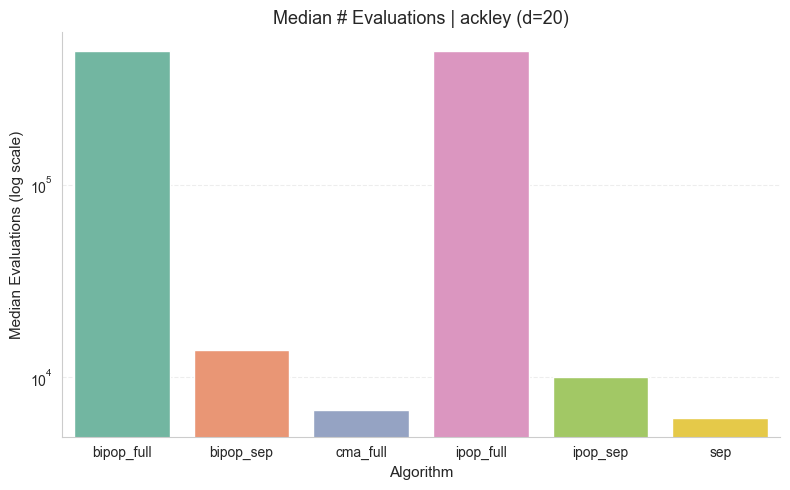

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


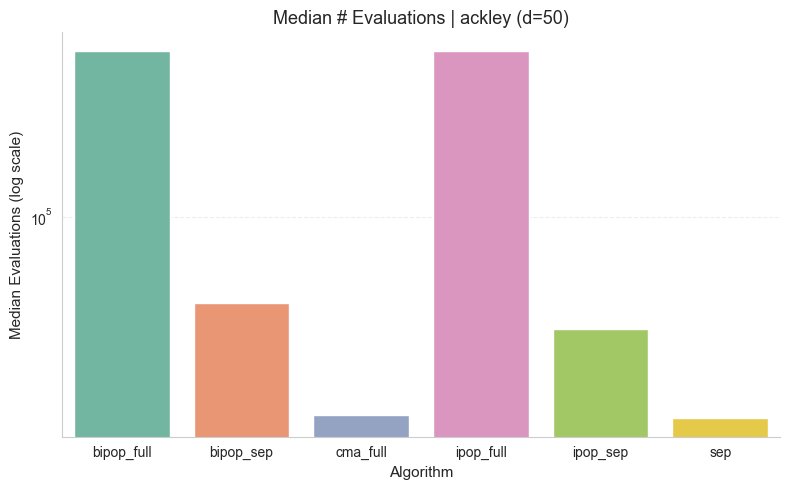

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


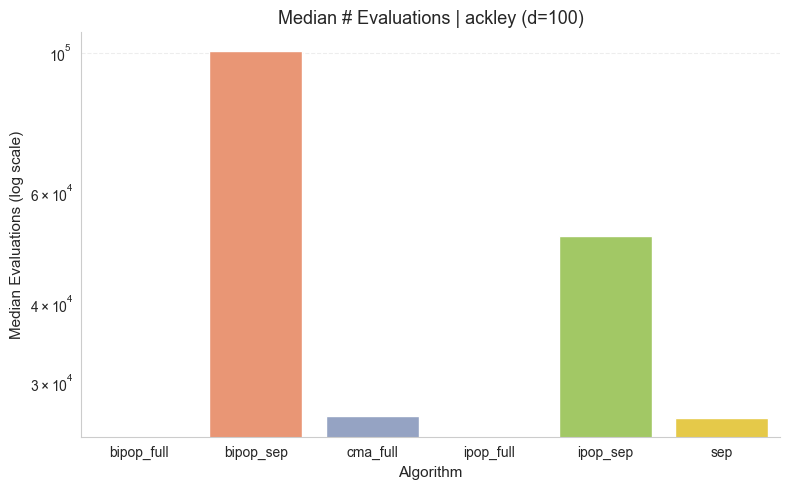

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


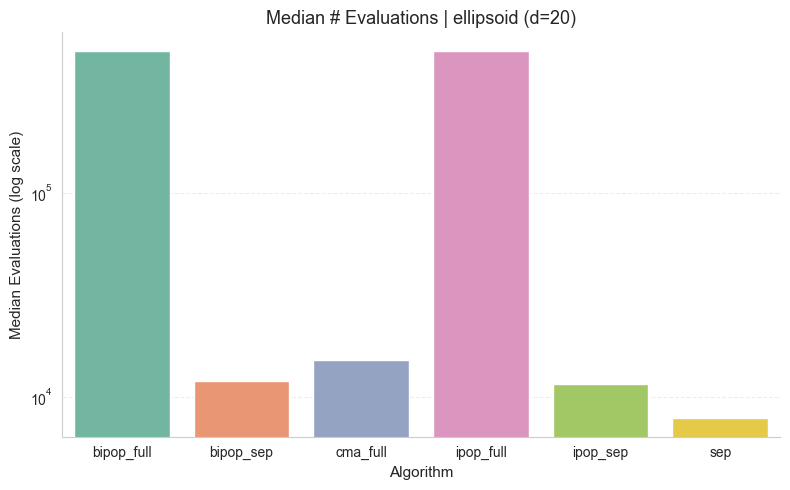

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


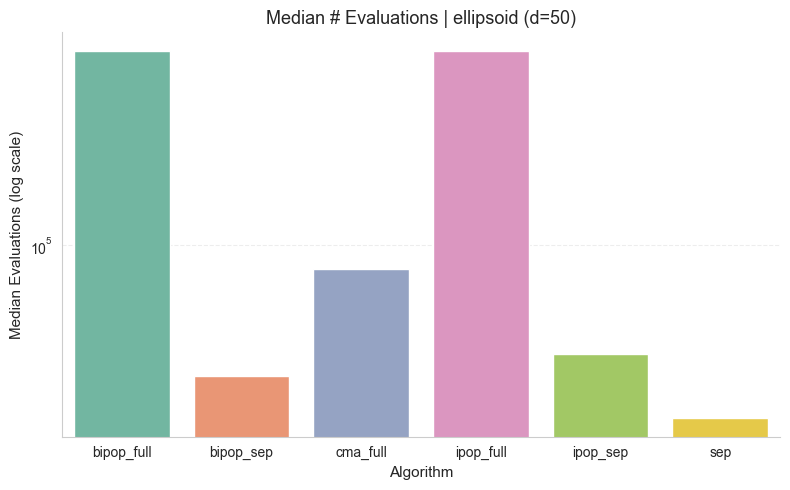

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


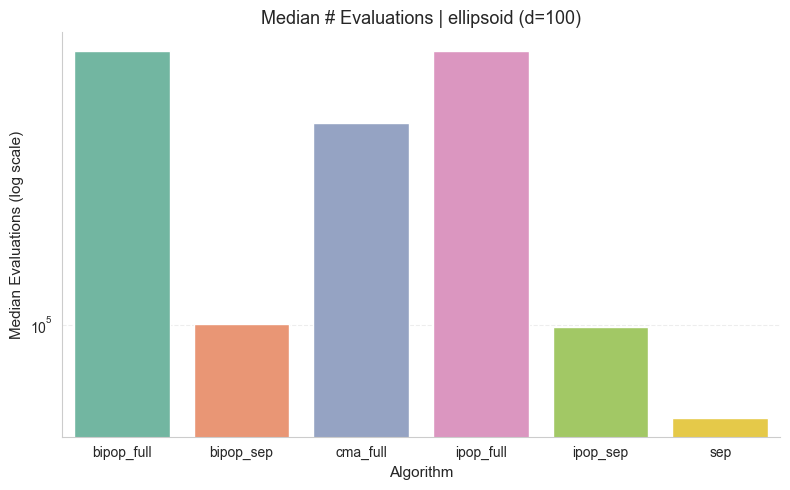

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


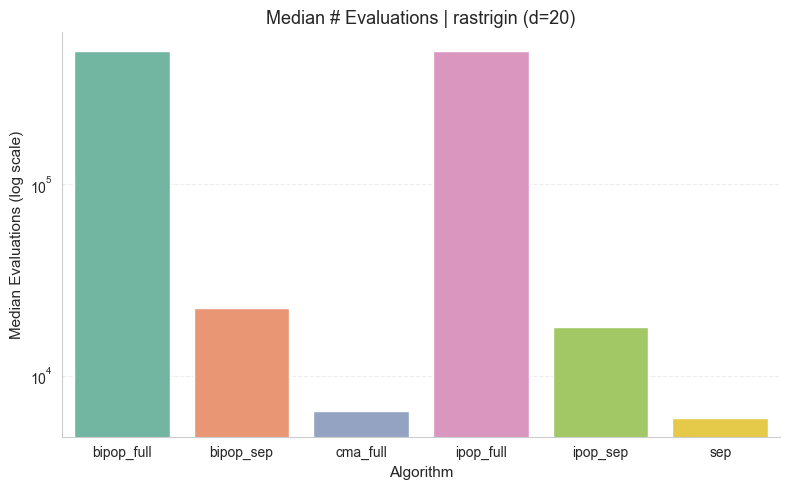

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


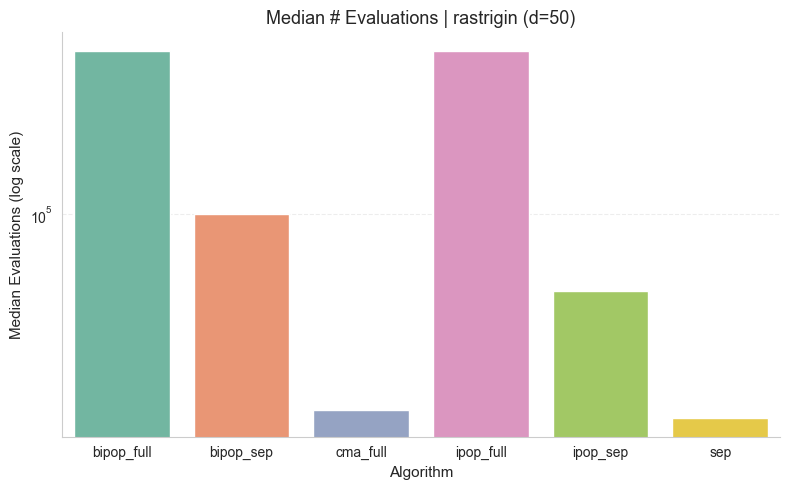

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


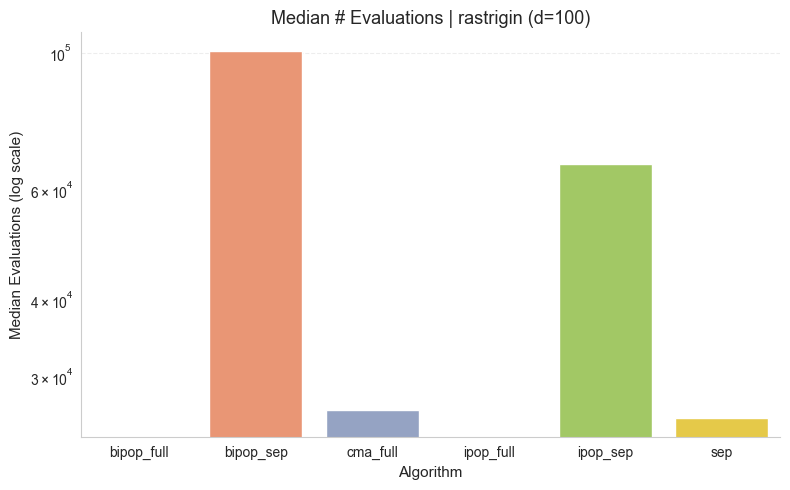

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


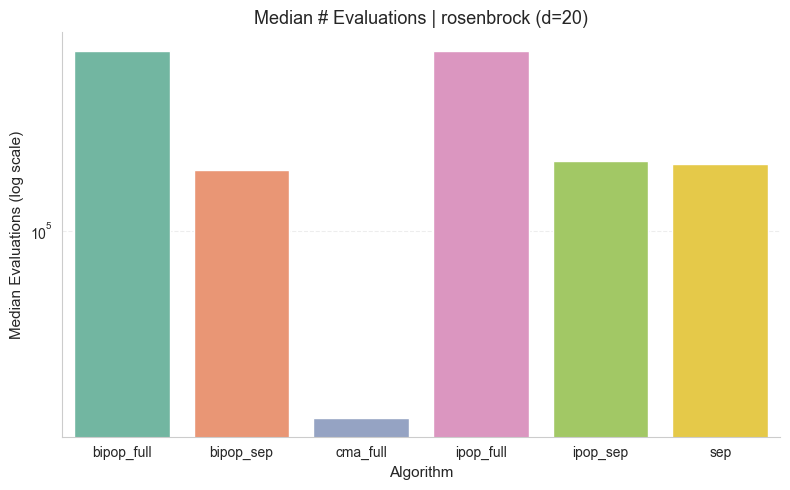

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


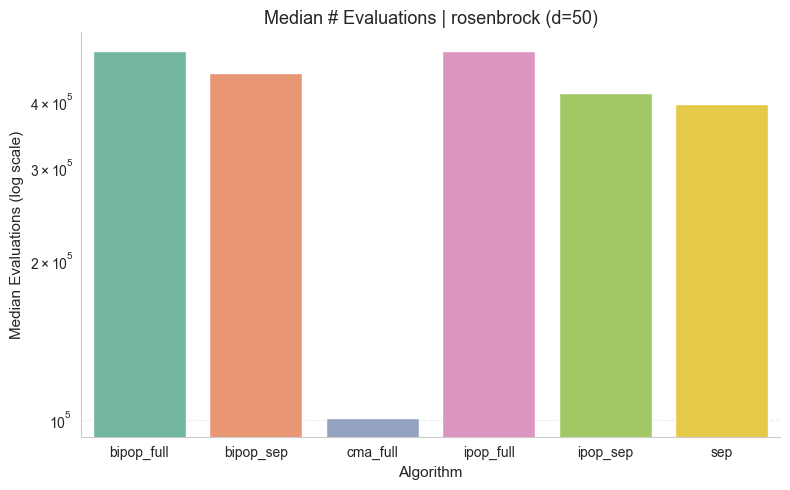

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


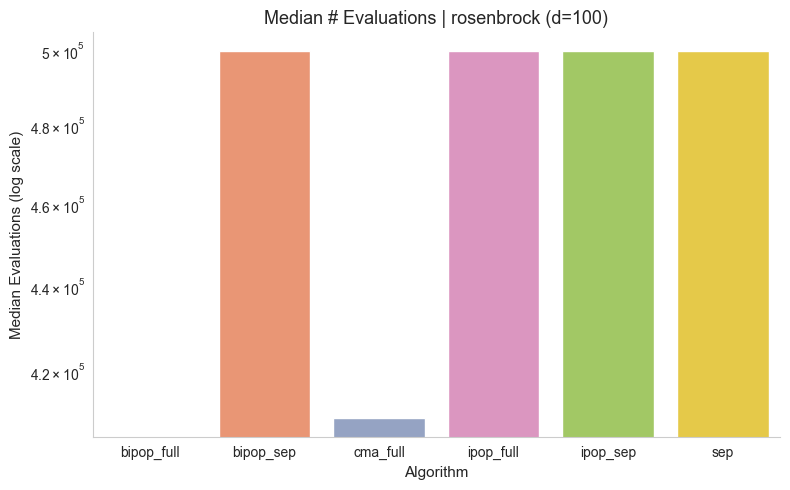

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


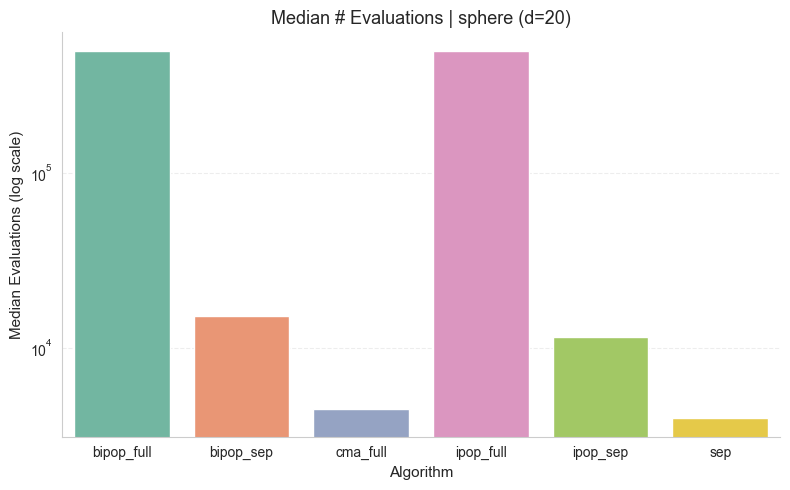

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


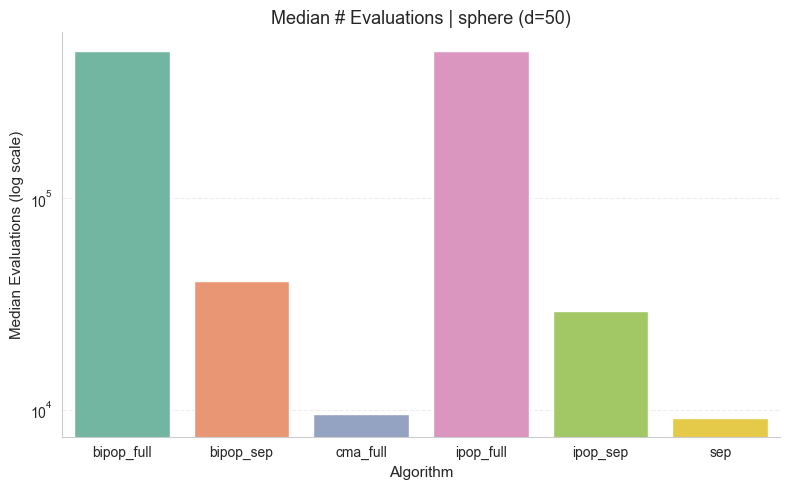

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\3362893007.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


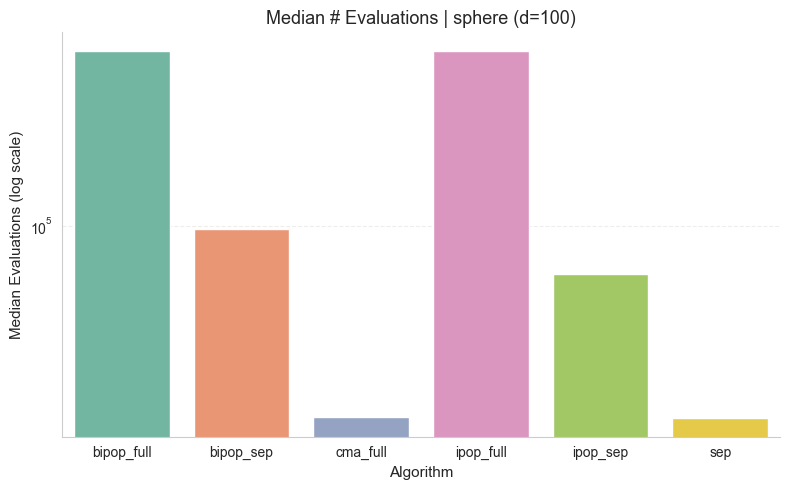

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use seaborn's clean style
sns.set_style("whitegrid")

# Only keep algorithms that actually have data
agg_valid = agg[agg['n_runs'] > 0].copy()

all_funcs = sorted(agg_valid['func'].unique())
all_dims  = sorted(agg_valid['dim'].unique())
all_algos = sorted(agg_valid['algo'].unique())

# Choose a clean, professional palette
palette = sns.color_palette("Set2", n_colors=len(all_algos))

for func in all_funcs:
    for dim in all_dims:

        sub = agg_valid[(agg_valid['func'] == func) & (agg_valid['dim'] == dim)]

        if sub.empty:
            continue

        sub = sub.sort_values('algo')   # consistent ordering

        plt.figure(figsize=(8, 5))
        ax = sns.barplot(
            data=sub,
            x='algo',
            y='median_evals',         # more stable than mean
            order=all_algos,
            palette=palette,
            dodge=False
        )

        ax.set_yscale('log')          # wide variation → log scale helps comprehension
        ax.set_title(f"Median # Evaluations | {func} (d={dim})", fontsize=13)
        ax.set_xlabel("Algorithm", fontsize=11)
        ax.set_ylabel("Median Evaluations (log scale)", fontsize=11)

        # Subtle grid for readability
        ax.grid(axis="y", linestyle="--", alpha=0.35)

        # Cleaner look → remove top + right spines
        sns.despine()

        plt.tight_layout()
        plt.show()


C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


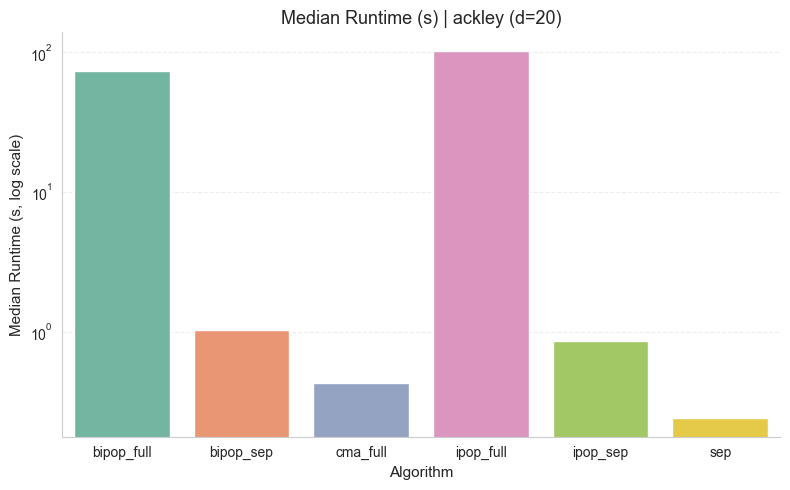

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


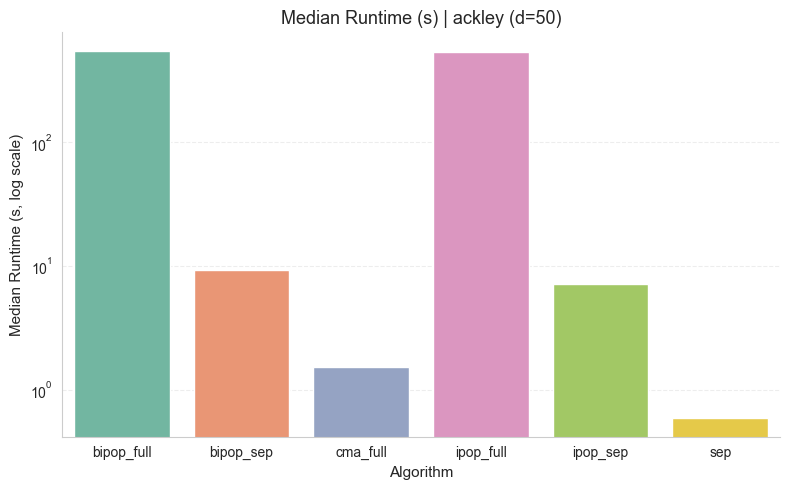

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


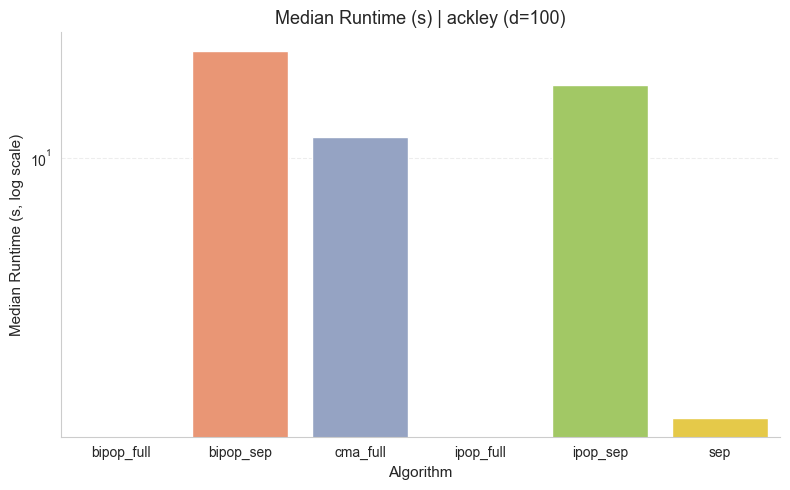

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


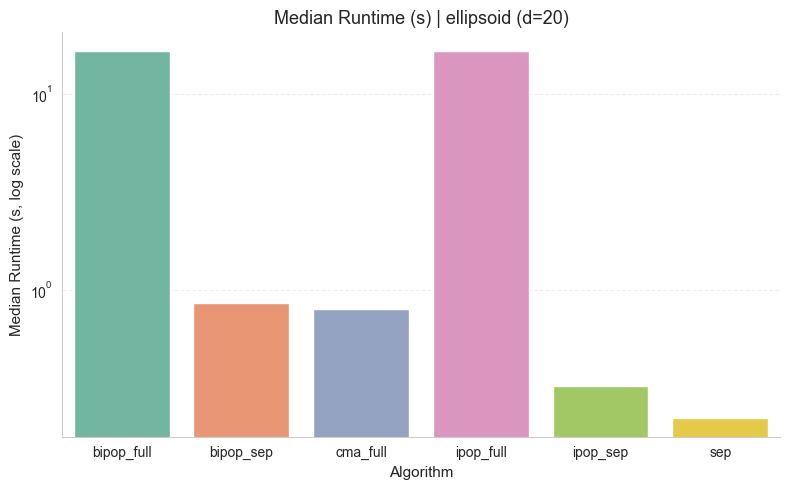

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


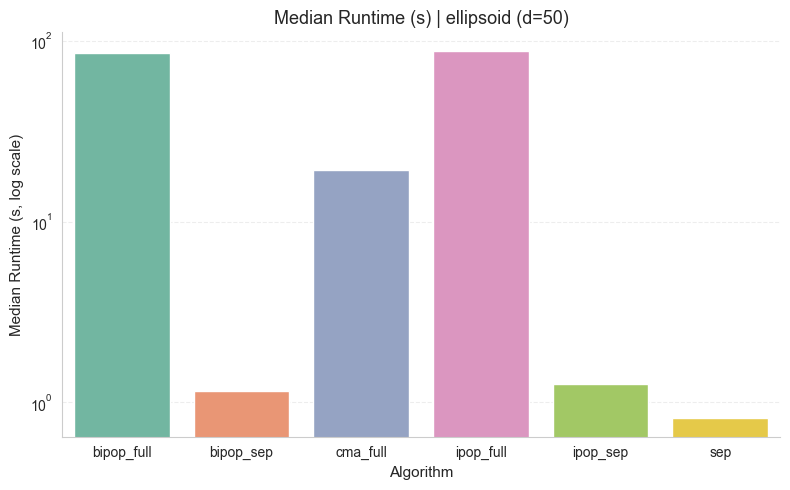

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


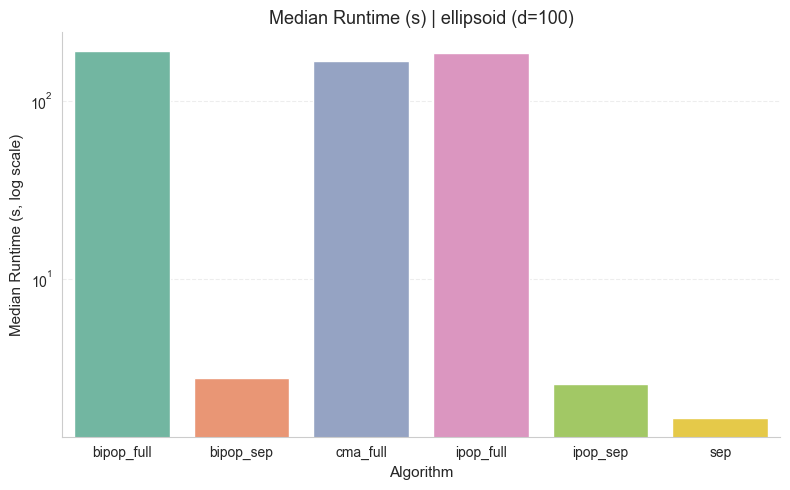

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


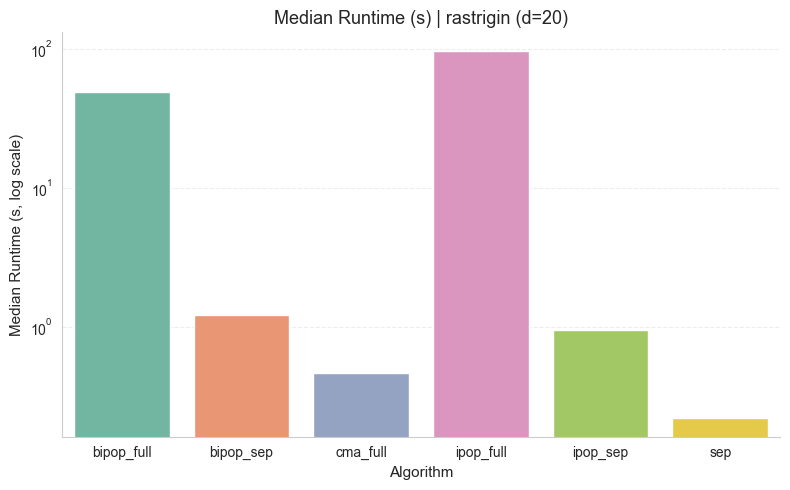

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


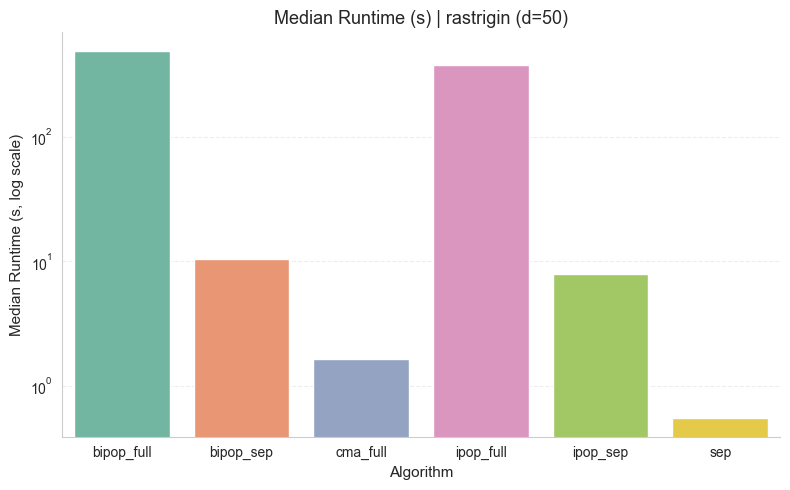

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


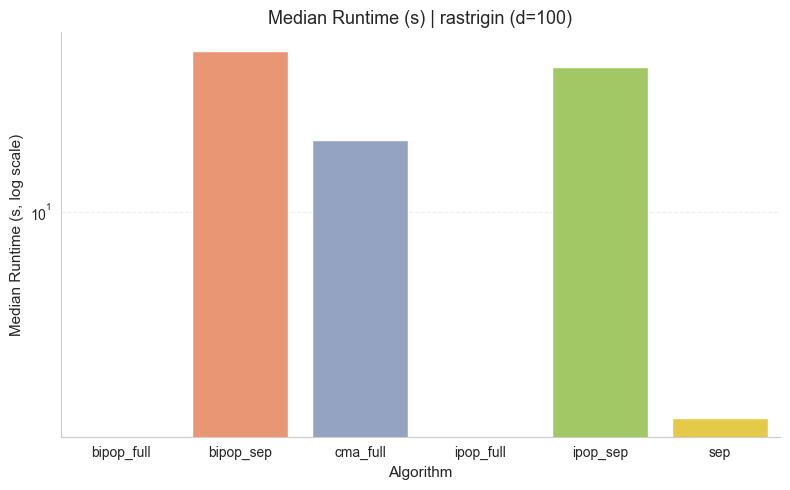

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


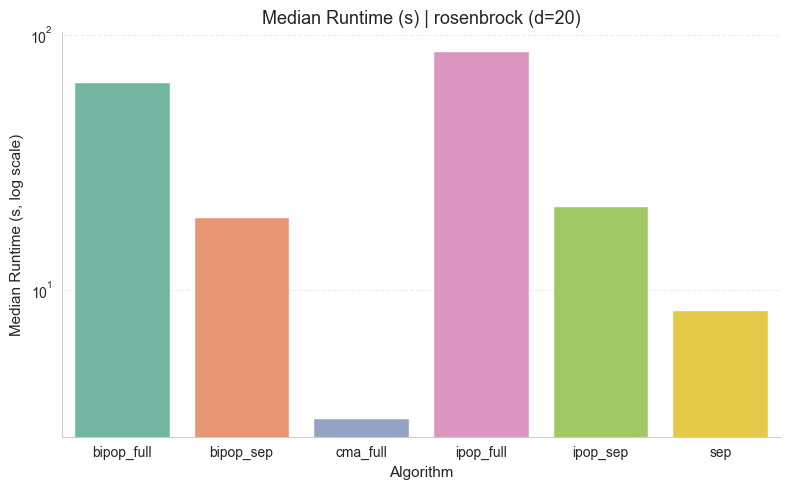

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


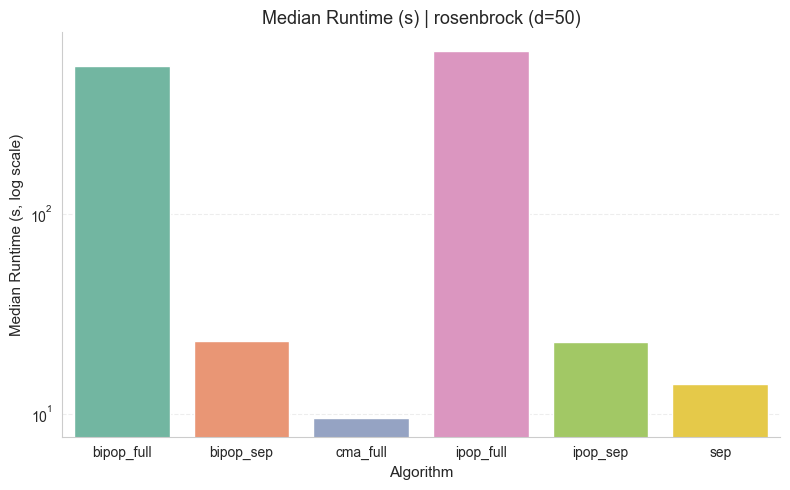

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


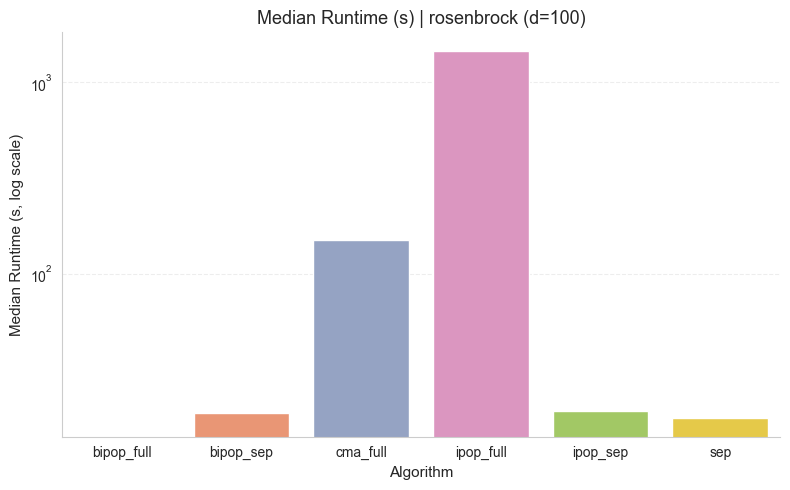

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


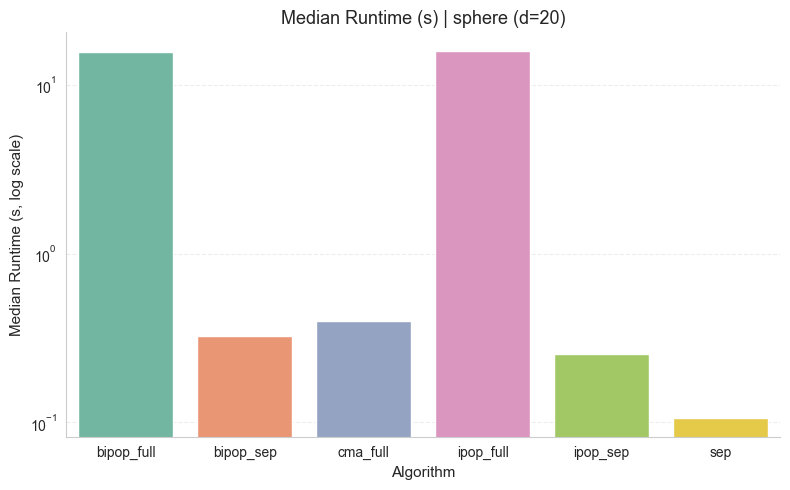

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


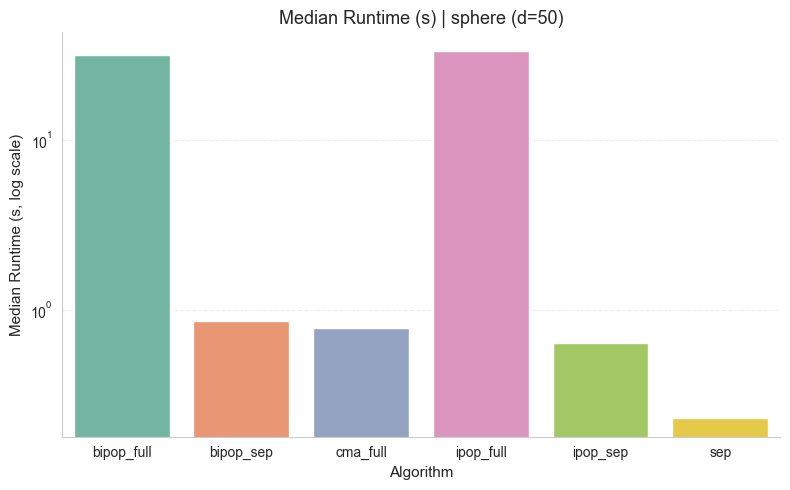

C:\Users\puray\AppData\Local\Temp\ipykernel_14412\1574492395.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


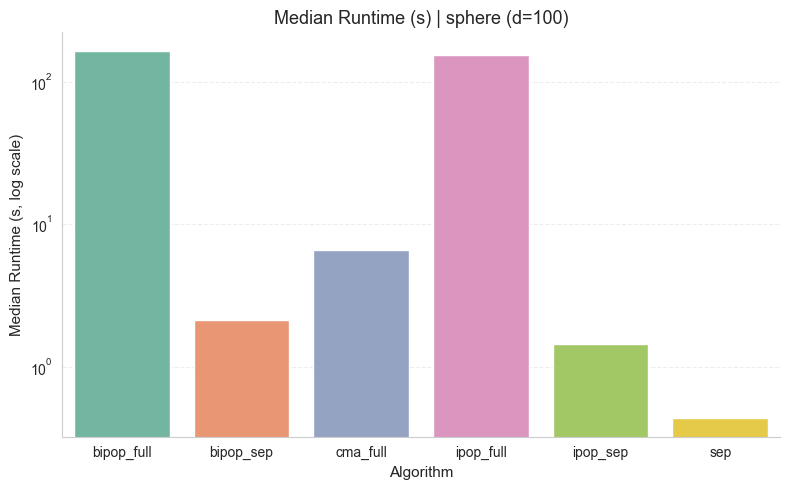

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


# Use only entries where something actually ran
agg_valid = agg[agg['n_runs'] > 0].copy()

all_funcs = sorted(agg_valid['func'].unique())
all_dims  = sorted(agg_valid['dim'].unique())
all_algos = sorted(agg_valid['algo'].unique())

# Nice, readable palette
palette = sns.color_palette("Set2", n_colors=len(all_algos))
sns.set_style("whitegrid")

for func in all_funcs:
    for dim in all_dims:

        sub = agg_valid[(agg_valid['func'] == func) & (agg_valid['dim'] == dim)].copy()
        if sub.empty:
            continue

        sub = sub.sort_values('algo')

        plt.figure(figsize=(8, 5))
        ax = sns.barplot(
            data=sub,
            x='algo',
            y='median_seconds',     # use median instead of mean for robustness
            order=all_algos,
            palette=palette,
            dodge=False
        )

        ax.set_yscale('log')
        ax.set_title(f"Median Runtime (s) | {func} (d={dim})", fontsize=13)
        ax.set_xlabel("Algorithm", fontsize=11)
        ax.set_ylabel("Median Runtime (s, log scale)", fontsize=11)
        ax.grid(axis='y', ls='--', alpha=0.35)
        sns.despine()

        plt.tight_layout()
        plt.show()


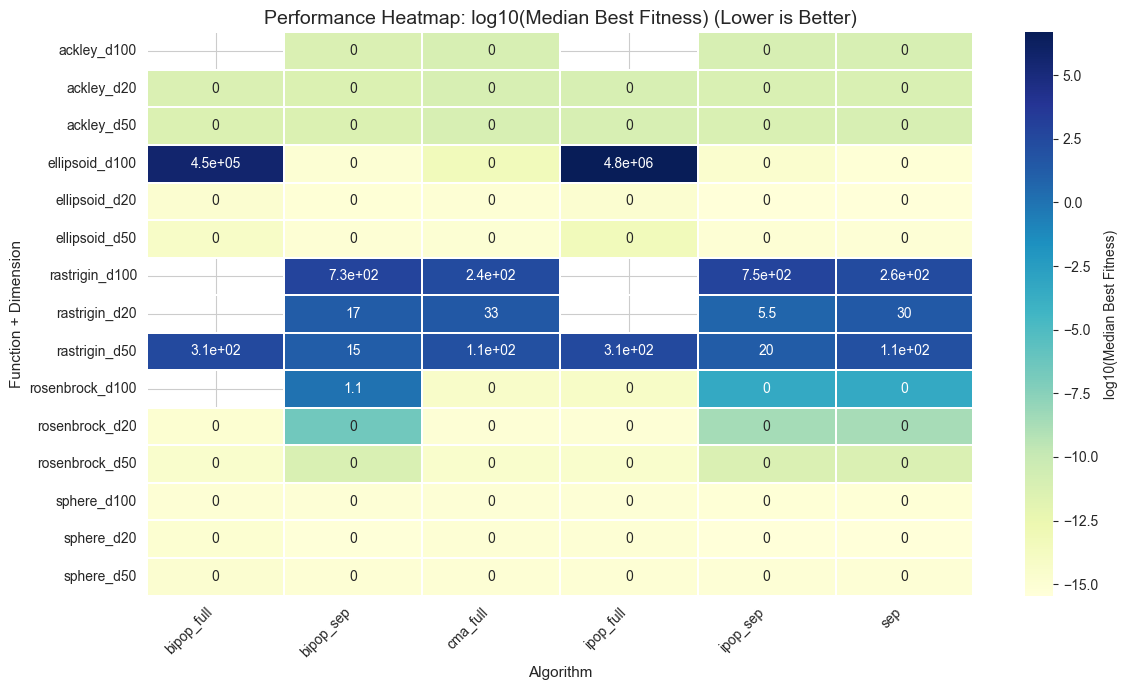

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Use only entries where at least one run exists
agg_valid = agg[agg['n_runs'] > 0].copy()

# Create a compact label combining function + dimension
agg_valid['func_dim'] = agg_valid['func'] + '_d' + agg_valid['dim'].astype(str)

# Pivot: rows = func_dim, columns = algo, values = median_best
pivot = agg_valid.pivot(index='func_dim', columns='algo', values='median_best')

# Take log10 for colour scale; replace 0 with NaN to avoid -inf
pivot_log = np.log10(pivot.replace(0, np.nan))

plt.figure(figsize=(12, max(6, pivot.shape[0] // 2)))
ax = sns.heatmap(
    pivot_log,
    # Annotate with the *actual* median best fitness (not log), rounded
    annot=pivot.round(2),
    fmt='.2g',
    cmap='YlGnBu',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'log10(Median Best Fitness)'},
    # Mask NaNs so "no data" cells appear blank
    mask=pivot_log.isna()
)

ax.set_title('Performance Heatmap: log10(Median Best Fitness) (Lower is Better)', fontsize=14)
ax.set_ylabel('Function + Dimension', fontsize=11)
ax.set_xlabel('Algorithm', fontsize=11)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


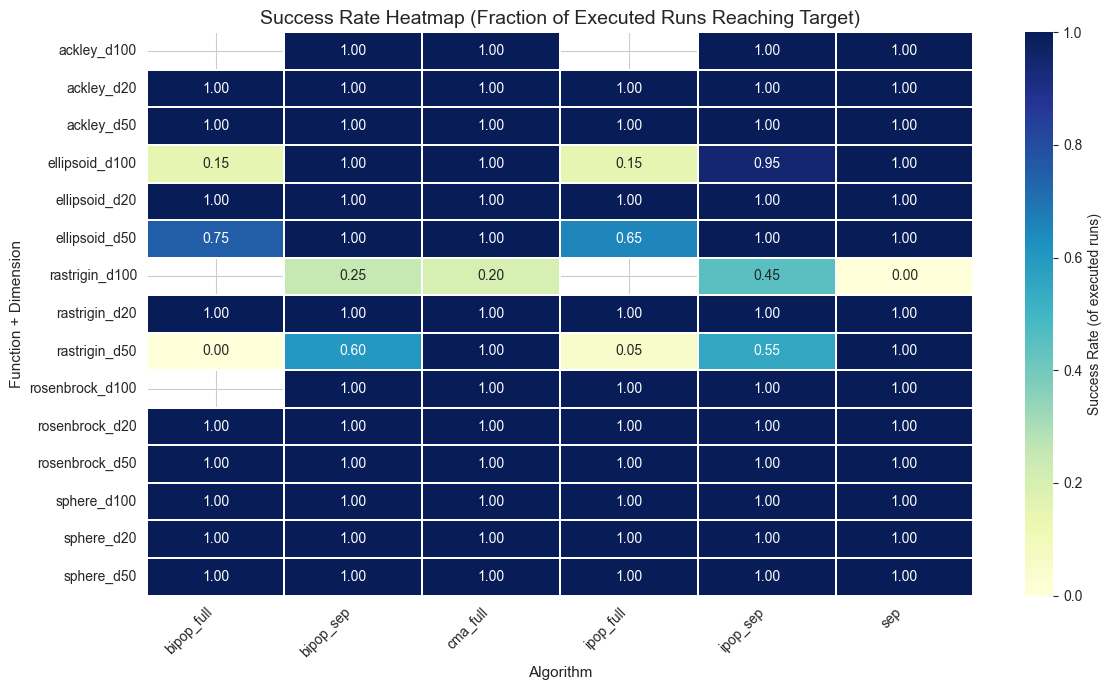

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


# Keep only (func, dim, algo) combos that actually have at least 1 run
agg_success = agg[agg['n_runs'] > 0].copy()

# Combine function and dimension into a single label
agg_success['func_dim'] = agg_success['func'] + '_d' + agg_success['dim'].astype(str)

# Pivot: rows = function+dimension, columns = algo, values = success rate of executed runs
# success_rate_actual = n_success / n_runs (should already be in agg_raw; if not, recompute)
if 'success_rate_actual' not in agg_success.columns:
    agg_success['success_rate_actual'] = (
        agg_success['n_success'] / agg_success['n_runs'].replace(0, pd.NA)
    )

pivot_success = agg_success.pivot(
    index='func_dim',
    columns='algo',
    values='success_rate_actual'
)

plt.figure(figsize=(12, max(6, pivot_success.shape[0] // 2)))
ax = sns.heatmap(
    pivot_success,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Success Rate (of executed runs)'}
)

ax.set_title('Success Rate Heatmap (Fraction of Executed Runs Reaching Target)', fontsize=14)
ax.set_ylabel('Function + Dimension', fontsize=11)
ax.set_xlabel('Algorithm', fontsize=11)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [16]:
restart_summary = (
    per_run
    .groupby('algo', as_index=False)
    .agg(
        n_runs=('seed', 'size'),
        median_restarts=('restarts_final', 'median'),
        mean_restarts=('restarts_final', 'mean'),
        success_rate=('run_success', 'mean')
    )
    .sort_values('median_restarts')
)

print("Overall restart behaviour per algorithm:")
display(restart_summary)


Overall restart behaviour per algorithm:


,algo,n_runs,median_restarts,mean_restarts,success_rate
2,cma_full,300,0.0,0.000000,0.946667
5,sep,300,0.0,0.000000,0.933333
4,ipop_sep,300,6.0,5.256667,0.930000
1,bipop_sep,300,6.0,5.156667,0.923333
0,bipop_full,240,9.0,8.920833,0.825000
3,ipop_full,260,10.0,9.876923,0.834615


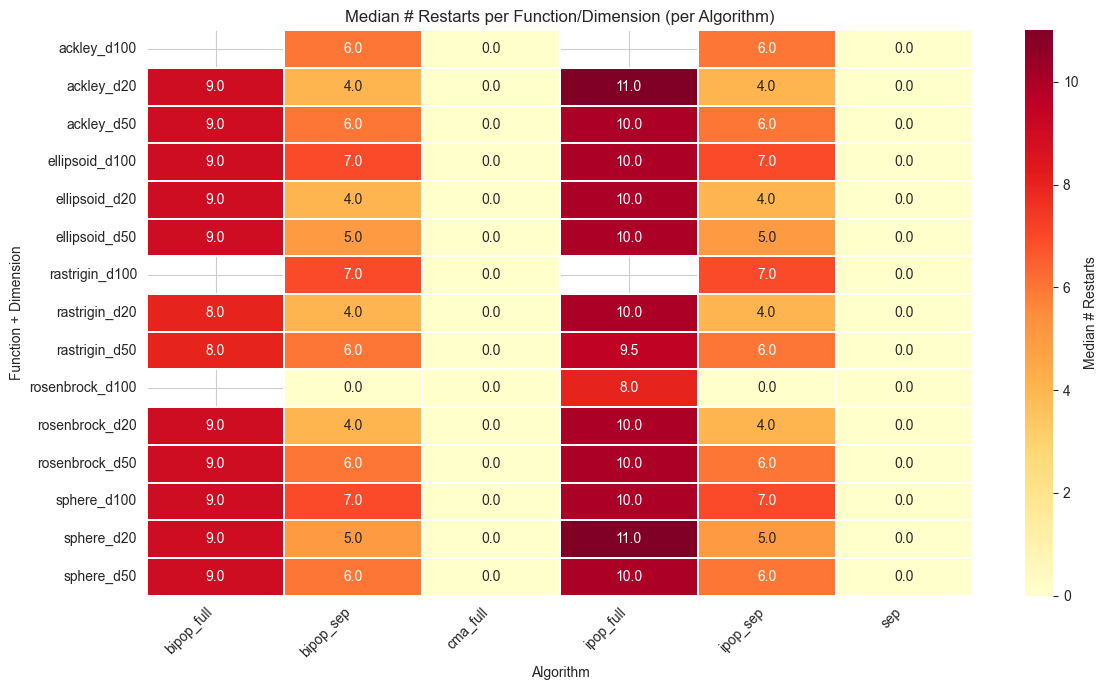

In [18]:
agg_restarts = (
    per_run
    .groupby(['func', 'dim', 'algo'], as_index=False)
    .agg(median_restarts=('restarts_final', 'median'))
)

agg_restarts['func_dim'] = agg_restarts['func'] + '_d' + agg_restarts['dim'].astype(str)

pivot_restarts = agg_restarts.pivot(
    index='func_dim',
    columns='algo',
    values='median_restarts'
)

plt.figure(figsize=(12, max(6, pivot_restarts.shape[0] // 2)))
ax = sns.heatmap(
    pivot_restarts,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Median # Restarts'}
)

ax.set_title('Median # Restarts per Function/Dimension (per Algorithm)')
ax.set_ylabel('Function + Dimension')
ax.set_xlabel('Algorithm')
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
